# Burst Analysis Quickstart

This notebook runs the same burst-analysis pipeline on either the `stimRemovalNull` NPZ recordings or the raw H5 recordings. Select the dataset in the configuration cell; downstream analysis cells use the common `RestingActivityDataset`/`Recording` objects and should not need dataset-specific edits.

For now it:

- loads one configured recording for detailed inspection,
- selects reference electrodes using the usual `PrepConfig`,
- shows the initial layout-grid and pooled IFR views via the standard `ephax` analyzers,
- computes per-electrode instantaneous firing-rate (IFR) traces on a shared time grid,
- separates low-activity, high-activity, and burst periods,
- builds aggregate activity-state and wave-speed summaries across configured wells/DIVs where available.


In [ ]:
%matplotlib inline

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "ephax").exists() and (repo_root.parent / "ephax").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

os.environ.setdefault("MPLCONFIGDIR", str((repo_root / ".mpl-cache").resolve()))

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import LogFormatterMathtext, LogLocator
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks, peak_prominences
from IPython.display import Image, display
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from ephax import RestingActivityDataset, PrepConfig
from ephax.metrics.layout_grid import compute_grid_avghz_per_recording
from ephax.modeling.gmm import fit_ifr_gmm
from ephax.metrics.ifr import IFRConfig, ifr_peaks, prepare_ifr_timeseries_panels
from ephax.metrics.ifr import calculate_ifr
from ephax.plotting import (
    draw_electrode_peak_time_map,
    plot_high_activity_burst_windows,
    plot_macro_burst_detector_comparison_windows,
    plot_population_ifr_summary,
    save_event_hex_gif,
    draw_wave_timing_panel,
    draw_wave_bootstrap_panel,
    plot_ifr_histogram,
    plot_ifr_timeseries_panels,
    draw_grid_avghz_panel,
)
from ephax.metrics import (
    activity_state_kde_peak_frequencies,
    align_highres_to_anchors,
    binned_kde_peak_summary,
    compute_electrode_peak_time_map,
    aggregate_wave_results as package_aggregate_wave_results,
    build_burst_peak_aligned_events as package_build_burst_peak_aligned_events,
    compute_or_load_wave_result as package_compute_or_load_wave_result,
    load_wave_result_cache as package_load_wave_result_cache,
    summarize_wave_recording_result as package_summarize_wave_recording_result,
    save_wave_result_cache as package_save_wave_result_cache,
    wave_settings_from_config as package_wave_settings_from_config,
    wave_cache_dir as package_wave_cache_dir,
    build_highres_traces,
    build_network_activity_state,
    build_participation_activity_state,
    build_population_ifr,
    build_trigger_summary,
    detect_coarse_burst_epochs,
    detect_nested_gamma_anchors,
    detect_network_burst_epochs,
    detect_participation_burst_epochs,
    detect_high_activity_epochs,
    extract_activity_state_ifr,
)

plt.rcParams["figure.dpi"] = 120
np.random.seed(0)


## Configure Recording and Burst View

The defaults below mirror the existing quickstart style: a 300 s recording-relative window and top-active electrode selection.


In [27]:
# Dataset switch: "stim_removal_null" or "raw_h5".
DATASET = "stim_removal_null"

# Single-recording selection. DIV is used by stimRemovalNull and ignored for raw H5.
WELL = 0
DIV = 12
RAW_H5_DIV = 40

STIM_DATA_ROOT = repo_root / "ephax/data/stimRemovalNull"
STIM_DATA_FILENAME_TEMPLATE = "DIV{div}_240703_data_well{well}_exp_data.npz"

H5_FILE_INFO = {
    0: ("ephax/data", "well_0.raw.h5", 0),
    1: ("ephax/data", "well_1.raw.h5", 1),
    2: ("ephax/data", "well_2_3.raw.h5", 2),
    3: ("ephax/data", "well_2_3.raw.h5", 3),
    4: ("ephax/data", "well_4.raw.h5", 4),
    5: ("ephax/data", "well_5.raw.h5", 5),
}

AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
AGGREGATE_DIVS = [DIV]

START_SEC = 0.0
END_SEC = 300.0 if DATASET == "stim_removal_null" else 600.0
MIN_AMP = 0.0

TOP_START = 0
TOP_STOP = 1000 if DATASET == "stim_removal_null" else 300

IFR_GRID_HZ = 50.0
IFR_MAX_HZ = 1000.0
SMOOTH_SIGMA_SEC = 0.15

BURST_MIN_DISTANCE_SEC = 1.0
BURST_PROMINENCE_QUANTILE = 0.90
BURST_PROMINENCE_SCALE = 0.20
BURST_WINDOW_SEC = 2.5

COARSE_EPOCH_REL_HEIGHT = 0.20
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
GAMMA_SEARCH_MS = 120.0
GAMMA_SEARCH_TO_EPOCH_END = True
GAMMA_MIN_DISTANCE_MS = 40.0
GAMMA_PROMINENCE_FRAC = 0.08
GAMMA_PROMINENCE_ABS_FLOOR = 0.10
GAMMA_KEEP_HEIGHT_FRAC = 0.50

NETWORK_BIN_MS = 10.0
NETWORK_ACTIVE_RATE_FLOOR_HZ = 1.0
NETWORK_THRESHOLD_BASELINE_QUANTILE = 0.20
NETWORK_THRESHOLD_IQR_SCALE = 3.0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_ACTIVE_ELECTRODES = 10
NETWORK_MERGE_GAP_MS = 50.0
NETWORK_MIN_DURATION_MS = 20.0
NETWORK_MIN_SPIKES = 20
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0
BURST_ANCHOR_WINDOW_MS = NETWORK_BIN_MS

ALIGN_PRE_MS = 20.0
ALIGN_POST_MS = 40.0
COND_PROP_DELAY_START_MS = -10.0
COND_PROP_DELAY_STOP_MS = 30.0
COND_PROP_WINDOW_HALF_WIDTH_MS = 1.0
COND_PROP_DISTANCE_BIN_UM = 100.0
COND_PROP_TRIGGER_SCOPE = "gamma"  # "gamma", "macro_burst", or "non_burst"
WAVE_X_BIN_UM = 300.0
WAVE_PEAK_SEARCH_START_MS = -15.0
WAVE_PEAK_SEARCH_STOP_MS = 20.0
WAVE_TRACE_SMOOTH_SIGMA_MS = 2.0
WAVE_MIN_ELECTRODES_PER_BIN = 5
WAVE_MIN_EVENTS_PER_BIN = 5
WAVE_BOOTSTRAP_REPS = 2000
WAVE_RANDOM_SEED = 0
WAVE_CACHE_ROOT = repo_root / "outputs" / f"{DATASET}_wave_results"
WAVE_FORCE_RECOMPUTE = False
AGGREGATE_WAVE_FORCE_RECOMPUTE = False
SAVE_INLINE_PLOTS = False
INLINE_PLOT_DPI = 180

SORT_PEAK_PRE_MS = 5.0
SORT_PEAK_POST_MS = 10.0
GIF_FRAME_STEP_MS = 2.0
EXAMPLE_GAMMA_EVENT_COUNT = 6
MACRO_BURST_ZOOM_COUNT = 4
MACRO_BURST_ZOOM_PAD_SEC = 0.40
EXAMPLE_EVENT_HEX_SAVE = False
EXAMPLE_EVENT_HEX_DIR = Path("GIFs/example_event_hex")
HEX_GRID_SIZE = 35 if DATASET == "stim_removal_null" else 50
ARRAY_X_MIN_UM = 0.0
ARRAY_Y_MIN_UM = 0.0
ARRAY_X_MAX_UM = 3850.0
ARRAY_Y_MAX_UM = 2100.0


def stim_recording_path(well, div):
    return STIM_DATA_ROOT / f"well{int(well)}" / STIM_DATA_FILENAME_TEMPLATE.format(div=int(div), well=int(well))


def build_recording_spec(well, div=None):
    if DATASET == "stim_removal_null":
        div = DIV if div is None else div
        path = stim_recording_path(well, div)
        if not path.exists():
            raise FileNotFoundError(f"Could not find stimRemovalNull recording file: {path}")
        return {
            "dataset": DATASET,
            "source": "npz",
            "path": path,
            "well": int(well),
            "div": int(div),
            "recording_id": f"stimRemovalNull_well{int(well)}_DIV{int(div)}",
            "label": f"stimRemovalNull well{int(well)} DIV{int(div)}",
            "source_file": path.name,
        }

    if DATASET == "raw_h5":
        if int(well) not in H5_FILE_INFO:
            raise ValueError(f"Unsupported raw H5 WELL={well}; available wells: {sorted(H5_FILE_INFO)}")
        h5_folder, h5_filename, h5_well_index = H5_FILE_INFO[int(well)]
        folder_path = repo_root / h5_folder
        file_path = folder_path / h5_filename
        if not file_path.exists():
            raise FileNotFoundError(f"Could not find raw H5 recording file: {file_path}")
        return {
            "dataset": DATASET,
            "source": "h5",
            "folder": folder_path,
            "filename": h5_filename,
            "path": file_path,
            "well": int(well),
            "h5_well_index": int(h5_well_index),
            "div": int(RAW_H5_DIV),
            "recording_id": f"raw_h5_well{int(well)}_DIV{int(RAW_H5_DIV)}",
            "label": f"raw H5 well{int(well)} DIV{int(RAW_H5_DIV)}",
            "source_file": h5_filename,
        }

    raise ValueError("DATASET must be 'stim_removal_null' or 'raw_h5'.")


def iter_aggregate_recording_specs():
    if DATASET == "stim_removal_null":
        for div in AGGREGATE_DIVS:
            for well in AGGREGATE_WELLS:
                path = stim_recording_path(well, div)
                if not path.exists():
                    print(f"Skipping missing recording: well{well} DIV{div}")
                    continue
                yield build_recording_spec(well, div)
        return

    for well in AGGREGATE_WELLS:
        if int(well) not in H5_FILE_INFO:
            print(f"Skipping unsupported raw H5 well: {well}")
            continue
        yield build_recording_spec(well)


def load_recording_from_spec(spec, *, start_sec=START_SEC, end_sec=END_SEC, min_amp=MIN_AMP):
    if spec["source"] == "npz":
        with np.load(spec["path"], allow_pickle=True) as data:
            sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
            frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
            rec_t0 = float(np.min(frameno) / sf_native) if frameno.size else 0.0
        file_info = [(str(spec["path"]), rec_t0 + float(start_sec), rec_t0 + float(end_sec), int(spec["well"]))]
        return RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=float(min_amp))

    if spec["source"] == "h5":
        file_info = [
            (str(spec["folder"]), spec["filename"], float(start_sec), float(end_sec), int(spec["h5_well_index"]))
        ]
        return RestingActivityDataset.from_file_info(file_info, source="h5", min_amp=float(min_amp))

    raise ValueError(f"Unsupported recording source: {spec['source']}")


recording_spec = build_recording_spec(WELL, DIV)
recording_label = recording_spec["label"]
GIF_OUTPUT_PATH = Path(f"GIFs/{recording_spec['recording_id']}_gamma_ifr_grid.gif")

recording_spec

INLINE_PLOT_OUTPUT_DIR = repo_root / "outputs" / "burst_analysis_inline_plots" / recording_spec["recording_id"]


def plot_filename(label):
    text = str(label).strip().lower()
    keep = []
    previous_underscore = False
    for char in text:
        if char.isalnum():
            keep.append(char)
            previous_underscore = False
        else:
            if not previous_underscore:
                keep.append("_")
                previous_underscore = True
    return "".join(keep).strip("_") or "plot"


def save_inline_plot(fig, name, *, show=True):
    if SAVE_INLINE_PLOTS:
        INLINE_PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        path = INLINE_PLOT_OUTPUT_DIR / f"{plot_filename(name)}.png"
        fig.savefig(path, dpi=int(INLINE_PLOT_DPI), bbox_inches="tight")
        print(f"Saved plot: {path}")
    if show:
        plt.show()
    return fig


In [28]:
ds = load_recording_from_spec(recording_spec)
rec = ds.recordings[0]

in_window = (rec.spikes["time"] >= rec.start_time) & (rec.spikes["time"] <= rec.end_time)
duration = float(rec.end_time - rec.start_time)
n_spikes = int(np.sum(in_window))
n_active_electrodes = int(np.unique(rec.spikes["electrode"][in_window]).size)

print(f"Loaded 1 recording: {recording_spec['label']}")
print(f"Source: {recording_spec['source_file']}")
print(f"Window: [{rec.start_time:.4f}, {rec.end_time:.4f}] s ({duration:.1f} s)")
print(f"Sampling rate: {rec.sf:.1f} Hz | spikes in window: {n_spikes:,} | active electrodes in window: {n_active_electrodes}")


Loaded 1 recording: stimRemovalNull well0 DIV12
Source: DIV12_240703_data_well0_exp_data.npz
Window: [-0.2286, 299.7714] s (300.0 s)
Sampling rate: 10000.0 Hz | spikes in window: 128,982 | active electrodes in window: 998


## Select Reference Electrodes

Use the same `PrepConfig` pattern as elsewhere in the repo, then keep the selected electrodes fixed for the burst analysis steps below.


In [29]:
prep_cfg = PrepConfig(mode="top", top_start=TOP_START, top_stop=TOP_STOP, verbose=False)
refs = ds.select_ref_electrodes(prep_cfg)[0]

print(f"Selected {refs.size} electrodes")
print("First 20 selected electrode ids:", refs[:20])


Selected 998 electrodes
First 20 selected electrode ids: [ 5695 15325 25351  2635  2177  2489 25327  7277 15657 17437  6429 20465
  6087 13873  4647  4657 18265 16705 20905 24867]


## Initial Layout and IFR Views

Before the burst-specific plots below, reuse the standard `ephax` visualizers on the same single-recording dataset and `PrepConfig` selection.


In [ ]:
recording_labels = [recording_label]

grids = compute_grid_avghz_per_recording(ds.recordings, grid_size=50.0, interpolate=False)
fig_layout, axes_layout = plt.subplots(1, 1, figsize=(5, 4), squeeze=False, constrained_layout=True)
draw_grid_avghz_panel(grids, axes_layout, recording_titles=recording_labels, compact=False, show_colorbar=True)
fig_layout.suptitle(f"{recording_label}: Layout Grid")
save_inline_plot(fig_layout, "layout_grid_average_hz", show=False)

grids_interp = compute_grid_avghz_per_recording(ds.recordings, grid_size=50.0, interpolate=True)
fig_layout_interp, axes_layout_interp = plt.subplots(1, 1, figsize=(5, 4), squeeze=False, constrained_layout=True)
draw_grid_avghz_panel(grids_interp, axes_layout_interp, recording_titles=recording_labels, compact=False, show_colorbar=True)
fig_layout_interp.suptitle(f"{recording_label}: Layout Grid (interpolated)")
save_inline_plot(fig_layout_interp, "layout_grid_average_hz_interpolated", show=False)

ifr_hist_bins = 200
ifr_cfg = IFRConfig(
    log_scale=True,
    overlay_gmm=True,
    ts_bins=200,
    time_grid_hz=200.0,
    max_time_points=2_000,
)
spikes_list = [rec.spikes for rec in ds.recordings]
start_times = [rec.start_time for rec in ds.recordings]
end_times = [rec.end_time for rec in ds.recordings]
refs_for_ifr = ds.select_ref_electrodes(prep_cfg)
peaks = ifr_peaks(
    spikes_list,
    start_times,
    end_times,
    log_scale=ifr_cfg.log_scale,
    selected_refs_per_recording=refs_for_ifr,
)

print(f"Collected {peaks.values.size} IFR samples")
if peaks.peaks_hz.size:
    print("IFR peak locations (Hz):", np.round(peaks.peaks_hz, 2))
else:
    print("No IFR peaks detected; consider widening the selection window.")

fit = fit_ifr_gmm(peaks.values, log_scale=ifr_cfg.log_scale, n_components=ifr_cfg.n_components) if ifr_cfg.overlay_gmm else None
fig_ifr_hist, _ = plot_ifr_histogram(peaks, ifr_cfg, fit=fit, hist_bins=ifr_hist_bins, show=True)
save_inline_plot(fig_ifr_hist, "ifr_histogram_gmm", show=False)

ifr_panels = prepare_ifr_timeseries_panels(
    spikes_list,
    start_times,
    end_times,
    refs_for_ifr,
    log_scale=ifr_cfg.log_scale,
    time_grid_hz=ifr_cfg.time_grid_hz,
    max_time_points=ifr_cfg.max_time_points,
)
for panel_idx, (fig_ts, _axes_ts) in enumerate(
    plot_ifr_timeseries_panels(
        ifr_panels,
        ifr_cfg,
        recording_titles=recording_labels,
        title=f"{recording_label}: IFR",
    )
):
    save_inline_plot(fig_ts, f"ifr_timeseries_panel_{panel_idx}", show=False)


## KDE-Based IFR Histograms

Plot pooled IFR samples on both linear and logarithmic axes using the same Gaussian KDE estimator. The maxima are extracted from the smoothed KDE curves in each coordinate system so we can compare dominant IFR modes without relying only on histogram binning.



In [ ]:
def collect_pooled_ifr_values_hz(dataset, selected_refs_per_recording):
    spikes_list = [rec.spikes for rec in dataset.recordings]
    start_times = [rec.start_time for rec in dataset.recordings]
    end_times = [rec.end_time for rec in dataset.recordings]
    pooled = []
    for spikes_data, start_time, end_time, selected_refs in zip(
        spikes_list,
        start_times,
        end_times,
        selected_refs_per_recording,
    ):
        _, _, ifr_vals = calculate_ifr(spikes_data, selected_refs, start_time, end_time)
        pooled.extend(ifr_vals)
    pooled = np.asarray(pooled, dtype=float)
    pooled = pooled[np.isfinite(pooled) & (pooled > 0) & (pooled <= IFR_MAX_HZ)]
    return pooled


ifr_positive_hz = collect_pooled_ifr_values_hz(ds, ifr_analyzer._refs_per_recording)
linear_hist = binned_kde_peak_summary(
    ifr_positive_hz,
    log_bins=False,
    n_bins=180,
    grid_size=4096,
    prominence_fraction=0.02,
    distance_fraction=0.01,
    bandwidth_scale=0.35,
    max_hz=IFR_MAX_HZ,
)
log_hist = binned_kde_peak_summary(
    ifr_positive_hz,
    log_bins=True,
    n_bins=180,
    grid_size=4096,
    prominence_fraction=0.02,
    distance_fraction=0.01,
    bandwidth_scale=0.35,
    max_hz=IFR_MAX_HZ,
)

ifr_kde_peak_summary = pd.DataFrame(
    {
        "axis": ["linear"] * linear_hist["peak_hz"].size + ["log_bins"] * log_hist["peak_hz"].size,
        "peak_hz": np.concatenate([linear_hist["peak_hz"], log_hist["peak_hz"]]),
        "peak_count": np.concatenate([linear_hist["peak_counts"], log_hist["peak_counts"]]),
    }
).sort_values(["axis", "peak_count"], ascending=[True, False], ignore_index=True)

print("Top binned-KDE peaks (linear bins):", np.round(linear_hist["peak_hz"][:6], 3))
print("Top binned-KDE peaks (log bins):", np.round(log_hist["peak_hz"][:6], 3))
ifr_kde_peak_summary.head(12)


## Build a Shared IFR Matrix

Each selected electrode gets interpolated onto the same time grid. The burst population trace is the pointwise mean across the selected electrodes.


In [ ]:
population = build_population_ifr(
    rec,
    refs,
    grid_hz=IFR_GRID_HZ,
    smooth_sigma_sec=SMOOTH_SIGMA_SEC,
)
burst_data = population

time_grid = population.time_grid
ifr_matrix = population.ifr_matrix
mean_ifr = population.mean_ifr
mean_ifr_smooth = population.mean_ifr_smooth

print(f"IFR matrix shape: {ifr_matrix.shape}")
print(f"Population mean range: {mean_ifr.min():.3f} to {mean_ifr.max():.3f} Hz")
print(f"Smoothed population mean range: {mean_ifr_smooth.min():.3f} to {mean_ifr_smooth.max():.3f} Hz")
global_positive_ifr = ifr_matrix[ifr_matrix > 0]
global_heatmap_vmin = max(1e-3, float(np.quantile(global_positive_ifr, 0.01)))
global_heatmap_vmax = float(global_positive_ifr.max())
print(f"Global heatmap log scale range: {global_heatmap_vmin:.4f} to {global_heatmap_vmax:.4f} Hz")


In [ ]:
fig, _ = plot_population_ifr_summary(
    population,
    heatmap_title="Per-electrode IFR on a shared time grid",
    mean_title="Average firing rate across selected electrodes (log y-scale)",
    mean_log_scale=True,
    smooth_sigma_sec=SMOOTH_SIGMA_SEC,
    figsize=(14, 8),
)
save_inline_plot(fig, "population_ifr_summary")


## Zoom Into a High-Activity Window

The full 300 s trace is useful for context, but a short zoom makes the cross-electrode burst structure easier to inspect.


In [ ]:
zoom_center_sec = float(time_grid[np.argmax(mean_ifr_smooth)])
zoom_half_width_sec = 5.0
zoom_start = max(time_grid[0], zoom_center_sec - zoom_half_width_sec)
zoom_stop = min(time_grid[-1], zoom_center_sec + zoom_half_width_sec)

fig, _ = plot_population_ifr_summary(
    population,
    time_range=(zoom_start, zoom_stop),
    heatmap_title=f"Zoomed IFR matrix: {zoom_start:.2f} s to {zoom_stop:.2f} s",
    mean_title="Zoomed average firing rate across selected electrodes (log y-scale)",
    mean_log_scale=True,
    smooth_sigma_sec=SMOOTH_SIGMA_SEC,
    figsize=(14, 8),
)
save_inline_plot(fig, "zoomed_population_ifr_summary")


## Nested Burst and Gamma Anchors

We now separate the problem into two scales:

- a **coarse burst epoch** on the slow population IFR trace
- a **nested gamma anchor** inside that burst using a high-resolution spike-density signal

This avoids treating several slow subpeaks from the same burst as independent events.


In [35]:
coarse_epochs, raw_peak_idx, raw_peak_props = detect_coarse_burst_epochs(
    time_grid,
    mean_ifr_smooth,
    grid_hz=IFR_GRID_HZ,
    peak_distance_sec=BURST_MIN_DISTANCE_SEC,
    prominence_quantile=BURST_PROMINENCE_QUANTILE,
    prominence_scale=BURST_PROMINENCE_SCALE,
    rel_height=COARSE_EPOCH_REL_HEIGHT,
)

highres = build_highres_traces(
    rec,
    refs,
    bin_ms=HIGHRES_BIN_MS,
    smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
)
highres_data = {
    "bin_edges_s": highres.bin_edges_s,
    "time_centers_s": highres.time_centers_s,
    "electrodes": highres.electrodes,
    "per_electrode_rate_hz": highres.per_electrode_rate_hz,
    "population_rate_hz": highres.population_rate_hz,
    "spikes_by_electrode": highres.spikes_by_electrode,
    "spike_presence": highres.spike_presence,
}

network_activity = build_network_activity_state(
    highres,
    aggregation_ms=NETWORK_BIN_MS,
    active_rate_floor_hz=NETWORK_ACTIVE_RATE_FLOOR_HZ,
    threshold_baseline_quantile=NETWORK_THRESHOLD_BASELINE_QUANTILE,
    threshold_iqr_scale=NETWORK_THRESHOLD_IQR_SCALE,
)
high_activity_epochs, high_activity_info = detect_high_activity_epochs(
    time_grid,
    mean_ifr_smooth,
    mad_scale=HIGH_ACTIVITY_MAD_SCALE,
    min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
    max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
)
participation_activity = build_participation_activity_state(
    highres,
    aggregation_ms=NETWORK_BIN_MS,
)
hierarchical_burst_epochs = detect_participation_burst_epochs(
    participation_activity,
    high_activity_epochs,
    min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
    min_duration_ms=NETWORK_MIN_DURATION_MS,
)

def assign_max_population_ifr_burst_anchors(highres_traces, burst_epochs):
    if burst_epochs.empty:
        return burst_epochs.copy()

    anchored = burst_epochs.copy()
    if "anchor_time_s" in anchored:
        anchored["participation_anchor_time_s"] = anchored["anchor_time_s"].astype(float)
    else:
        anchored["participation_anchor_time_s"] = np.nan
    anchored["anchor_method"] = "max_highres_population_ifr"

    for idx, row in anchored.iterrows():
        mask = (
            (highres_traces.time_centers_s >= float(row["start_time_s"]))
            & (highres_traces.time_centers_s <= float(row["end_time_s"]))
        )
        local_indices = np.flatnonzero(mask)
        if local_indices.size == 0:
            continue
        local_rate = highres_traces.population_rate_hz[local_indices]
        anchor_idx = int(local_indices[int(np.nanargmax(local_rate))])
        anchored.loc[idx, "anchor_time_s"] = float(highres_traces.time_centers_s[anchor_idx])
        anchored.loc[idx, "coarse_peak_time_s"] = float(highres_traces.time_centers_s[anchor_idx])
        anchored.loc[idx, "coarse_peak_idx"] = anchor_idx
        anchored.loc[idx, "coarse_peak_hz"] = float(highres_traces.population_rate_hz[anchor_idx])
        anchored.loc[idx, "anchor_population_rate_hz"] = float(highres_traces.population_rate_hz[anchor_idx])
    return anchored


hierarchical_burst_epochs = assign_max_population_ifr_burst_anchors(
    highres,
    hierarchical_burst_epochs,
)

analysis_epochs = hierarchical_burst_epochs.copy()
analysis_anchors = analysis_epochs.copy()
if not analysis_anchors.empty:
    analysis_anchors["coarse_event_idx"] = analysis_anchors["event_idx"].astype(int)
    analysis_anchors["gamma_peak_rank"] = 0
    analysis_anchors["onset_time_s"] = analysis_anchors["start_time_s"].astype(float)
    analysis_anchors["anchor_height_hz"] = analysis_anchors["anchor_population_rate_hz"].astype(float)
    analysis_anchors["gamma_anchor_delay_ms"] = (analysis_anchors["anchor_time_s"] - analysis_anchors["onset_time_s"]) * 1000.0
    analysis_anchors["anchor_type"] = "max_highres_population_ifr"

network_coarse_epochs = detect_network_burst_epochs(
    network_activity,
    min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
    min_active_electrodes=NETWORK_MIN_ACTIVE_ELECTRODES,
    merge_gap_ms=NETWORK_MERGE_GAP_MS,
    min_duration_ms=NETWORK_MIN_DURATION_MS,
    min_spikes=NETWORK_MIN_SPIKES,
)
network_nested_anchors = detect_nested_gamma_anchors(
    network_coarse_epochs,
    highres,
    coarse_rel_height=COARSE_EPOCH_REL_HEIGHT,
    bin_ms=HIGHRES_BIN_MS,
    search_ms=GAMMA_SEARCH_MS,
    search_to_epoch_end=GAMMA_SEARCH_TO_EPOCH_END,
    min_distance_ms=GAMMA_MIN_DISTANCE_MS,
    prominence_frac=GAMMA_PROMINENCE_FRAC,
    prominence_abs_floor=GAMMA_PROMINENCE_ABS_FLOOR,
    keep_height_frac=GAMMA_KEEP_HEIGHT_FRAC,
)

nested_anchors = detect_nested_gamma_anchors(
    coarse_epochs,
    highres,
    coarse_rel_height=COARSE_EPOCH_REL_HEIGHT,
    bin_ms=HIGHRES_BIN_MS,
    search_ms=GAMMA_SEARCH_MS,
    search_to_epoch_end=GAMMA_SEARCH_TO_EPOCH_END,
    min_distance_ms=GAMMA_MIN_DISTANCE_MS,
    prominence_frac=GAMMA_PROMINENCE_FRAC,
    prominence_abs_floor=GAMMA_PROMINENCE_ABS_FLOOR,
    keep_height_frac=GAMMA_KEEP_HEIGHT_FRAC,
)

print(f"Raw slow peaks: {len(raw_peak_idx)}")
print(f"Rate-peak coarse burst epochs: {len(coarse_epochs)}")
print(f"Participation-gated coarse burst epochs: {len(network_coarse_epochs)}")
print(f"High-activity periods: {len(high_activity_epochs)}")
print(f"Nested high-activity participation bursts: {len(hierarchical_burst_epochs)}")
print(f"High-activity threshold: {high_activity_info['threshold_hz']:.3f} Hz")
print(f"Rate-peak nested gamma anchors: {len(nested_anchors)}")
print(f"Participation-gated nested gamma anchors: {len(network_nested_anchors)}")

comparison_summary = pd.DataFrame(
    [
        {
            "method": "rate_peak",
            "n_macro_bursts": len(coarse_epochs),
            "n_burst_peak_anchors": len(coarse_epochs),
            "n_gamma_anchors": len(nested_anchors),
            "anchor_type": "rate_peak_plus_nested_gamma",
            "total_macro_duration_s": float((coarse_epochs["end_time_s"] - coarse_epochs["start_time_s"]).sum()) if not coarse_epochs.empty else 0.0,
        },
        {
            "method": "network_participation",
            "n_macro_bursts": len(network_coarse_epochs),
            "n_burst_peak_anchors": len(network_coarse_epochs),
            "n_gamma_anchors": len(network_nested_anchors),
            "anchor_type": "participation_epoch_plus_nested_gamma",
            "total_macro_duration_s": float((network_coarse_epochs["end_time_s"] - network_coarse_epochs["start_time_s"]).sum()) if not network_coarse_epochs.empty else 0.0,
        },
        {
            "method": "high_activity_participation",
            "n_macro_bursts": len(analysis_epochs),
            "n_burst_peak_anchors": len(analysis_anchors),
            "n_gamma_anchors": np.nan,
            "anchor_type": "max_highres_population_ifr",
            "total_macro_duration_s": float((analysis_epochs["end_time_s"] - analysis_epochs["start_time_s"]).sum()) if not analysis_epochs.empty else 0.0,
        },
    ]
)
display(comparison_summary.round(3))

display(analysis_anchors[[
    "event_idx",
    "high_activity_event_idx",
    "start_time_s",
    "end_time_s",
    "anchor_time_s",
    "participation_anchor_time_s",
    "anchor_participation_fraction",
    "anchor_population_rate_hz",
    "peak_active_electrodes",
    "participating_electrodes",
    "duration_ms",
    "anchor_type",
]].head(10).round(3))


Raw slow peaks: 28
Rate-peak coarse burst epochs: 14
Participation-gated coarse burst epochs: 49
High-activity periods: 14
Nested high-activity participation bursts: 64
High-activity threshold: 0.194 Hz
Rate-peak nested gamma anchors: 24
Participation-gated nested gamma anchors: 119


,method,n_macro_bursts,n_burst_peak_anchors,n_gamma_anchors,anchor_type,total_macro_duration_s
0,rate_peak,14,14,24.0,rate_peak_plus_nested_gamma,43.62
1,network_participation,49,49,119.0,participation_epoch_plus_nested_gamma,17.13
2,high_activity_participation,64,64,NaN,max_highres_population_ifr,4.78


,event_idx,high_activity_event_idx,start_time_s,end_time_s,anchor_time_s,participation_anchor_time_s,anchor_participation_fraction,anchor_population_rate_hz,peak_active_electrodes,participating_electrodes,duration_ms,anchor_type
0,0,0,15.991,16.031,16.020,16.016,0.064,7.325,64,157,40.0,max_highres_population_ifr
1,1,0,16.081,16.171,16.113,16.156,0.214,25.459,214,640,90.0,max_highres_population_ifr
2,2,0,16.281,16.331,16.308,16.306,0.086,9.328,86,237,50.0,max_highres_population_ifr
3,3,0,17.181,17.281,17.221,17.216,0.153,22.479,153,525,100.0,max_highres_population_ifr
4,4,0,17.401,17.461,17.420,17.416,0.090,10.497,90,280,60.0,max_highres_population_ifr
5,5,0,18.101,18.191,18.137,18.136,0.067,7.582,67,307,90.0,max_highres_population_ifr
6,6,1,40.151,40.211,40.197,40.196,0.083,9.215,83,221,60.0,max_highres_population_ifr
7,7,1,40.251,40.351,40.337,40.336,0.214,23.324,214,646,100.0,max_highres_population_ifr
8,8,1,40.481,40.531,40.497,40.496,0.102,10.412,102,268,50.0,max_highres_population_ifr
9,9,2,61.671,61.711,61.702,61.706,0.085,9.572,85,188,40.0,max_highres_population_ifr


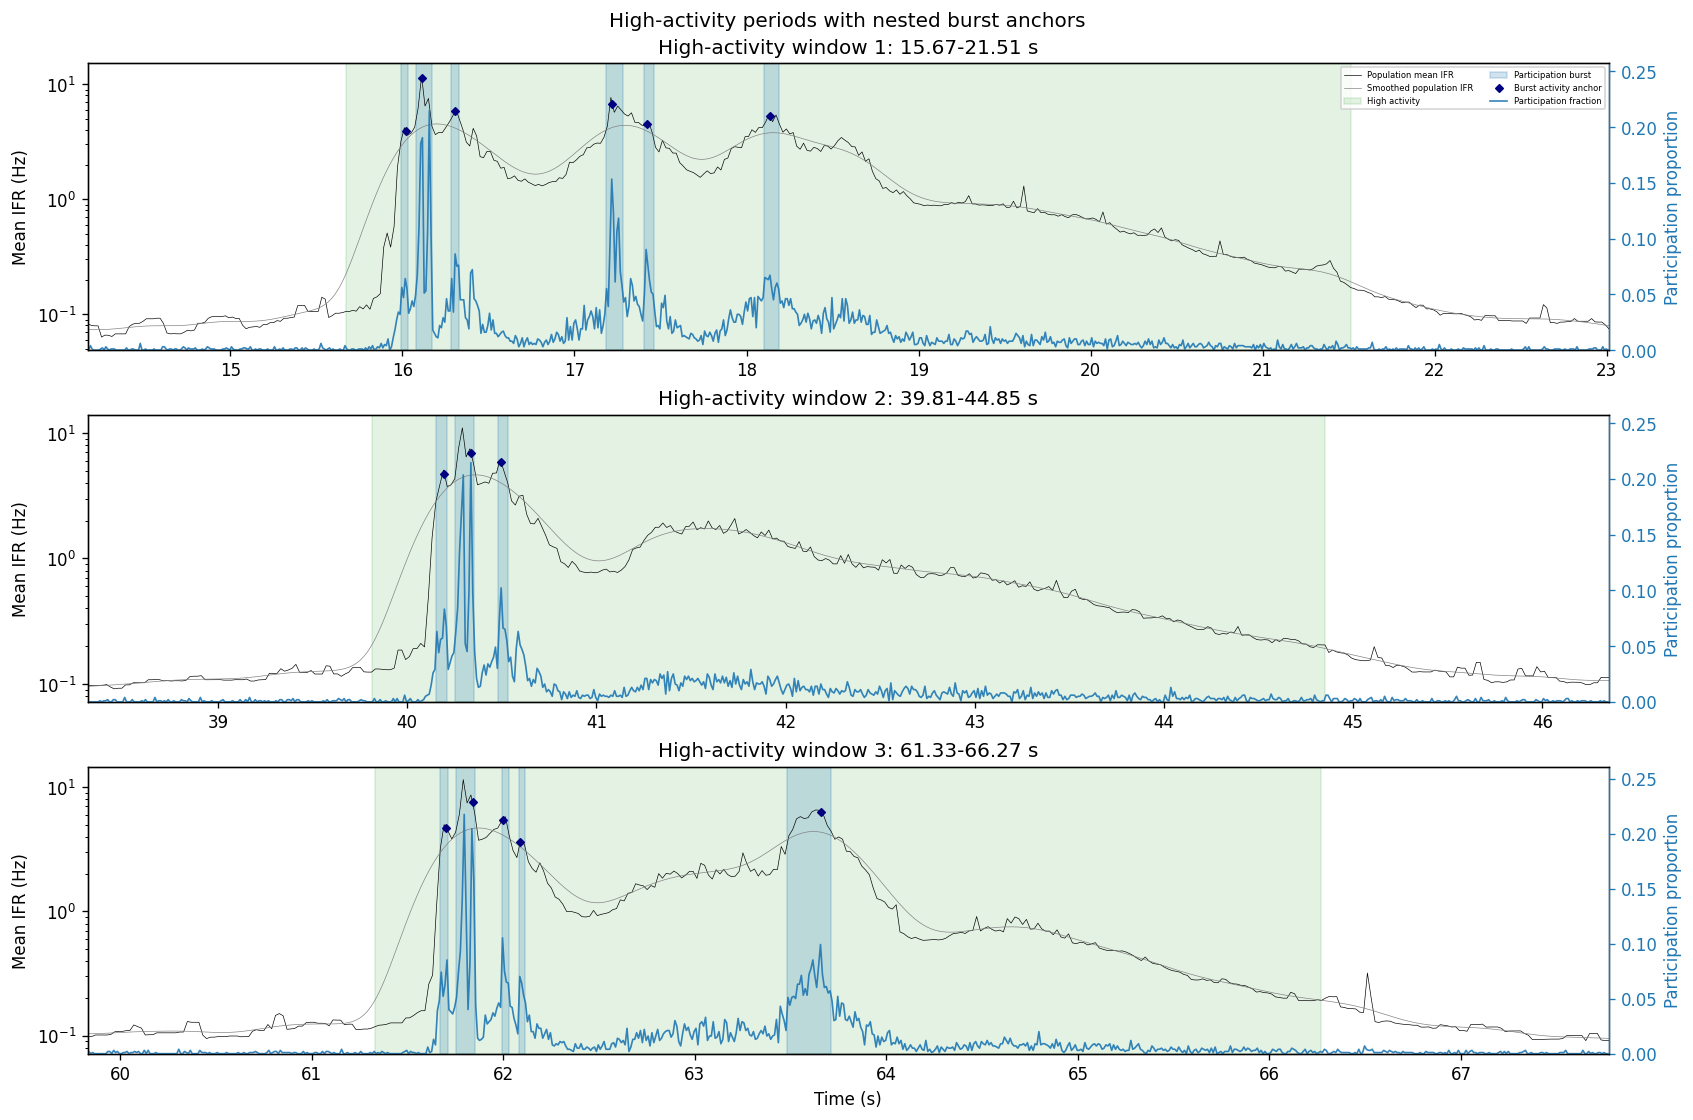

,event_idx,start_idx,end_idx,start_time_s,end_time_s,peak_idx,peak_time_s,peak_mean_ifr_hz,duration_ms,threshold_hz,baseline_hz
0,0,795,1086,15.671,21.511,821,16.191,4.519,5840.0,0.194,0.112
1,1,2002,2253,39.811,44.851,2029,40.351,4.640,5040.0,0.194,0.112
2,2,3078,3324,61.331,66.271,3105,61.871,4.700,4940.0,0.194,0.112
3,3,4070,4363,81.171,87.051,4138,82.531,4.767,5880.0,0.194,0.112
4,4,5214,5465,104.051,109.091,5241,104.591,4.679,5040.0,0.194,0.112
5,5,6269,6512,125.151,130.031,6386,127.491,4.487,4880.0,0.194,0.112
6,6,7568,7820,151.131,156.191,7595,151.671,4.752,5060.0,0.194,0.112
7,7,8774,9036,175.251,180.511,8803,175.831,4.788,5260.0,0.194,0.112
8,8,9712,9964,194.011,199.071,9740,194.571,4.952,5060.0,0.194,0.112
9,9,10729,10974,214.351,219.271,10757,214.911,4.836,4920.0,0.194,0.112


,event_idx,high_activity_event_idx,start_time_s,end_time_s,anchor_time_s,participation_anchor_time_s,anchor_participation_fraction,anchor_population_rate_hz,peak_active_electrodes,participating_electrodes,total_spikes,duration_ms
0,0,0,15.991,16.031,16.020,16.016,0.064,7.325,64,157,236,40.0
1,1,0,16.081,16.171,16.113,16.156,0.214,25.459,214,640,1134,90.0
2,2,0,16.281,16.331,16.308,16.306,0.086,9.328,86,237,337,50.0
3,3,0,17.181,17.281,17.221,17.216,0.153,22.479,153,525,905,100.0
4,4,0,17.401,17.461,17.420,17.416,0.090,10.497,90,280,387,60.0
5,5,0,18.101,18.191,18.137,18.136,0.067,7.582,67,307,542,90.0
6,6,1,40.151,40.211,40.197,40.196,0.083,9.215,83,221,384,60.0
7,7,1,40.251,40.351,40.337,40.336,0.214,23.324,214,646,1204,100.0
8,8,1,40.481,40.531,40.497,40.496,0.102,10.412,102,268,362,50.0
9,9,2,61.671,61.711,61.702,61.706,0.085,9.572,85,188,287,40.0


In [36]:
fig, axes = plot_high_activity_burst_windows(
    time_grid=time_grid,
    mean_ifr=mean_ifr,
    mean_ifr_smooth=mean_ifr_smooth,
    network_activity=participation_activity,
    high_activity_epochs=high_activity_epochs,
    burst_epochs=hierarchical_burst_epochs,
    high_activity_threshold_hz=high_activity_info["threshold_hz"],
    participation_threshold=NETWORK_MIN_PARTICIPATION_FRACTION,
    n_windows=3,
    pad_s=max(1.5, float(MACRO_BURST_ZOOM_PAD_SEC)),
)
fig.suptitle(
    "High-activity periods with nested burst anchors",
    y=1.02,
)
save_inline_plot(fig, "high_activity_burst_windows")

display(high_activity_epochs.head(10).round(3))
display(hierarchical_burst_epochs[[
    "event_idx",
    "high_activity_event_idx",
    "start_time_s",
    "end_time_s",
    "anchor_time_s",
    "participation_anchor_time_s",
    "anchor_participation_fraction",
    "anchor_population_rate_hz",
    "peak_active_electrodes",
    "participating_electrodes",
    "total_spikes",
    "duration_ms",
]].head(12).round(3))


## Burst-Window IFR Summary
Use the shared `plot_ifr_summary` view for representative windows that were designated as bursts. The burst span and refined max-participation anchor are overlaid on the population summary panel.


In [ ]:
if analysis_epochs.empty:
    raise ValueError("No hierarchical participation bursts were detected for burst-window summaries.")

burst_event_ids = (
    analysis_epochs.sort_values("anchor_population_rate_hz", ascending=False)["event_idx"]
    .head(int(MACRO_BURST_ZOOM_COUNT))
    .to_numpy(dtype=int)
)
burst_event_ids = np.sort(burst_event_ids)

for event_id in burst_event_ids:
    burst_row = analysis_epochs.loc[analysis_epochs["event_idx"] == int(event_id)].iloc[0]
    view_start = max(float(time_grid[0]), float(burst_row["start_time_s"]) - float(MACRO_BURST_ZOOM_PAD_SEC))
    view_stop = min(float(time_grid[-1]), float(burst_row["end_time_s"]) + float(MACRO_BURST_ZOOM_PAD_SEC))
    if np.count_nonzero((time_grid >= view_start) & (time_grid <= view_stop)) < 2:
        continue

    fig, _ = plot_population_ifr_summary(
        population,
        time_range=(view_start, view_stop),
        heatmap_title=f"Burst-window IFR matrix: event {int(event_id)} ({view_start:.2f}-{view_stop:.2f} s)",
        mean_title=(
            f"Designated burst window {int(event_id)}: "
            f"{float(burst_row['start_time_s']):.3f}-{float(burst_row['end_time_s']):.3f} s"
        ),
        mean_log_scale=True,
        smooth_sigma_sec=SMOOTH_SIGMA_SEC,
        figsize=(14, 8),
    )
    save_inline_plot(fig, f"burst_window_ifr_event_{int(event_id)}")


## IFR Histogram by Activity State
Split raw ISI-derived IFR samples into low-activity, high-activity non-burst, and burst periods. The histogram uses stacked bars so each IFR bin shows how much each activity state contributes to the same IFR range.


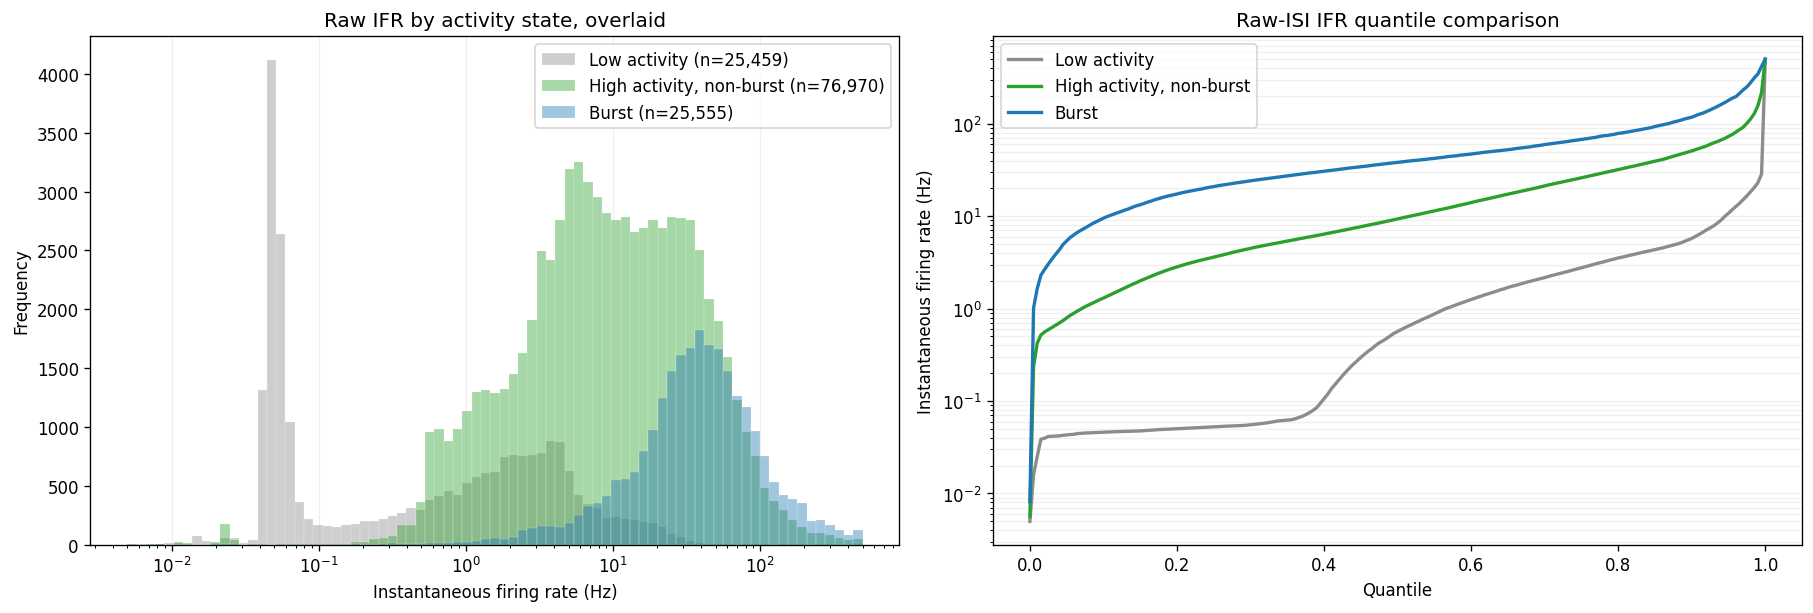

,period,n_samples,median_ifr_hz,mean_ifr_hz,p90_ifr_hz,p99_ifr_hz
0,low_activity,25459,0.566,2.464,5.735,23.011
1,high_activity,76970,9.337,20.918,50.761,156.250
2,burst,25555,38.168,56.963,117.647,344.828


In [38]:
state_ifr_positive = extract_activity_state_ifr(
    rec,
    refs,
    high_activity_epochs,
    analysis_epochs,
    max_hz=IFR_MAX_HZ,
)
for state, vals in state_ifr_positive.items():
    if vals.size == 0:
        raise ValueError(f"No positive raw IFR values were found for state: {state}")

all_state_ifr = np.concatenate(list(state_ifr_positive.values()))
hist_floor_hz = max(1e-3, float(np.min(all_state_ifr)))
hist_ceiling_hz = float(np.max(all_state_ifr))
if np.isclose(hist_floor_hz, hist_ceiling_hz):
    hist_ceiling_hz = hist_floor_hz * 10.0
hist_bins_hz = np.logspace(np.log10(hist_floor_hz), np.log10(hist_ceiling_hz), 80)

state_order = ["low_activity", "high_activity", "burst"]
state_labels = {
    "low_activity": "Low activity",
    "high_activity": "High activity, non-burst",
    "burst": "Burst",
}
state_colors = {
    "low_activity": "0.55",
    "high_activity": "tab:green",
    "burst": "tab:blue",
}
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for state in state_order:
    axes[0].hist(
        state_ifr_positive[state],
        bins=hist_bins_hz,
        color=state_colors[state],
        alpha=0.42,
        edgecolor="white",
        linewidth=0.25,
        label=f"{state_labels[state]} (n={state_ifr_positive[state].size:,})",
    )
axes[0].set_xscale("log")
axes[0].set_xlabel("Instantaneous firing rate (Hz)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Raw IFR by activity state, overlaid")
axes[0].legend(loc="upper right")
axes[0].grid(True, axis="x", alpha=0.18)

quantile_grid = np.linspace(0.0, 1.0, 201)
for state in state_order:
    axes[1].plot(
        quantile_grid,
        np.quantile(state_ifr_positive[state], quantile_grid),
        color=state_colors[state],
        lw=2.0,
        label=state_labels[state],
    )
axes[1].set_yscale("log")
axes[1].set_xlabel("Quantile")
axes[1].set_ylabel("Instantaneous firing rate (Hz)")
axes[1].set_title("Raw-ISI IFR quantile comparison")
axes[1].legend(loc="upper left")
axes[1].grid(True, which="both", axis="y", alpha=0.18)
save_inline_plot(fig, "single_recording_ifr_by_activity_state")

summary_rows = []
for state in state_order:
    vals = state_ifr_positive[state]
    summary_rows.append(
        {
            "period": state,
            "n_samples": int(vals.size),
            "median_ifr_hz": float(np.median(vals)),
            "mean_ifr_hz": float(np.mean(vals)),
            "p90_ifr_hz": float(np.quantile(vals, 0.90)),
            "p99_ifr_hz": float(np.quantile(vals, 0.99)),
        }
    )
burst_ifr_positive = state_ifr_positive["burst"]
pd.DataFrame(summary_rows).round(3)


## Aggregate IFR Histogram by Activity State Across Wells
Run the same low-activity / high-activity / burst split for each requested well and DIV, then pool raw ISI-derived IFR samples by activity state for an aggregate histogram.


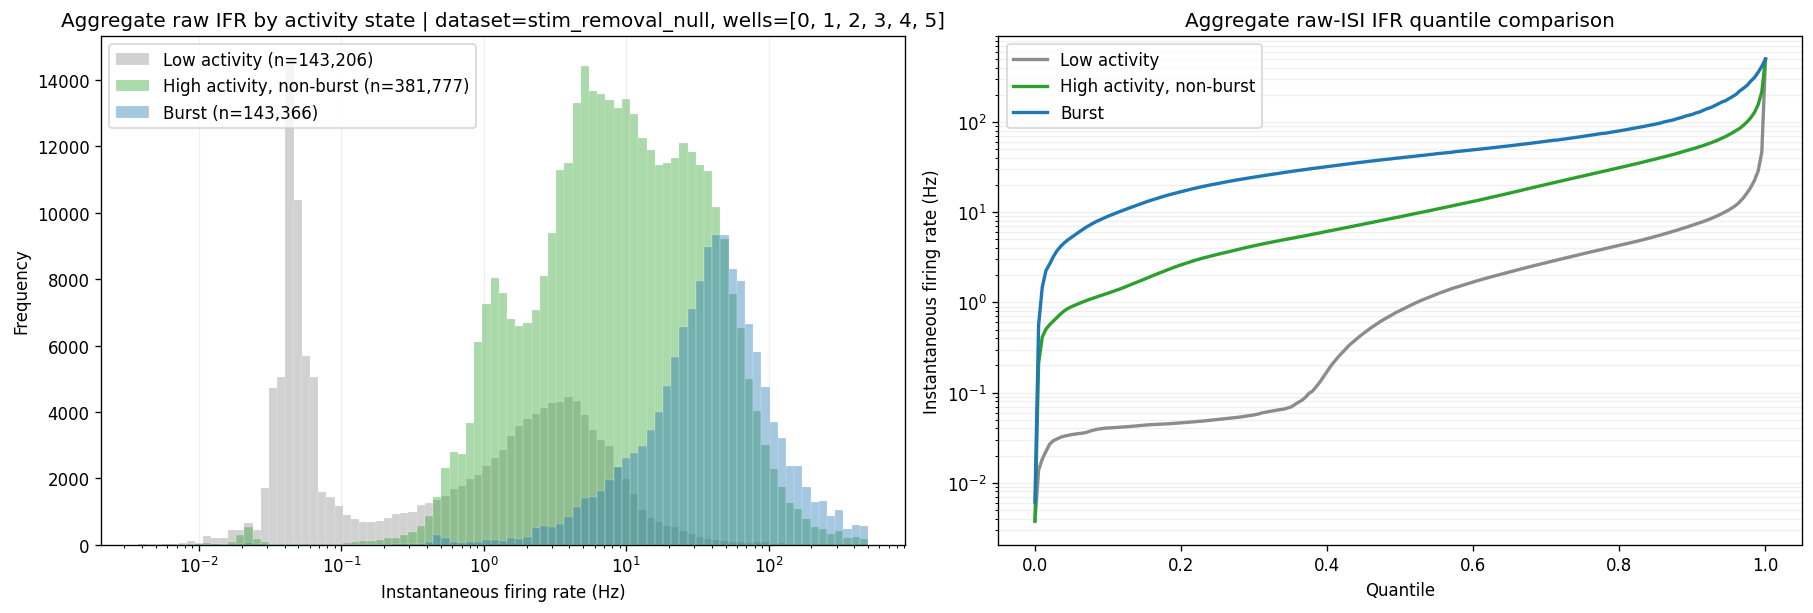

,well,div,recording_id,dataset,source_file,n_refs,n_high_activity_periods,n_bursts,high_activity_threshold_hz,total_high_activity_duration_s,total_burst_duration_s,n_low_activity_ifr_samples,n_high_activity_ifr_samples,n_burst_ifr_samples
0,0,12,stimRemovalNull_well0_DIV12,stim_removal_null,DIV12_240703_data_well0_exp_data.npz,998,14,64,0.194,69.52,4.78,25459,76970,25555
1,1,12,stimRemovalNull_well1_DIV12,stim_removal_null,DIV12_240703_data_well1_exp_data.npz,1000,11,67,0.126,62.72,4.50,16987,64251,26612
2,2,12,stimRemovalNull_well2_DIV12,stim_removal_null,DIV12_240703_data_well2_exp_data.npz,986,14,44,0.201,73.74,2.58,28819,69684,14290
3,3,12,stimRemovalNull_well3_DIV12,stim_removal_null,DIV12_240703_data_well3_exp_data.npz,1000,11,61,0.203,56.28,3.70,29384,62141,20439
4,4,12,stimRemovalNull_well4_DIV12,stim_removal_null,DIV12_240703_data_well4_exp_data.npz,980,16,53,0.153,64.40,3.55,23470,54368,18696
5,5,12,stimRemovalNull_well5_DIV12,stim_removal_null,DIV12_240703_data_well5_exp_data.npz,994,14,75,0.153,51.94,5.97,19087,54363,37774


,div,n_recordings,n_wells,mean_high_activity_periods,mean_bursts,total_high_activity_duration_s,total_burst_duration_s,total_low_activity_ifr_samples,total_high_activity_ifr_samples,total_burst_ifr_samples
0,12,6,6,13.333,60.667,378.6,25.08,143206,381777,143366


In [39]:
aggregate_state_chunks = {state: [] for state in state_order}
aggregate_rows = []
aggregate_prep_cfg = PrepConfig(mode="top", top_start=TOP_START, top_stop=TOP_STOP, verbose=False)

for spec_i in iter_aggregate_recording_specs():
    ds_i = load_recording_from_spec(spec_i)
    rec_i = ds_i.recordings[0]
    refs_i = ds_i.select_ref_electrodes(aggregate_prep_cfg)[0]
    population_i = build_population_ifr(rec_i, refs_i, grid_hz=IFR_GRID_HZ, smooth_sigma_sec=SMOOTH_SIGMA_SEC)
    highres_i = build_highres_traces(rec_i, refs_i, bin_ms=HIGHRES_BIN_MS, smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS)
    high_epochs_i, high_info_i = detect_high_activity_epochs(
        population_i.time_grid,
        population_i.mean_ifr_smooth,
        mad_scale=HIGH_ACTIVITY_MAD_SCALE,
        min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
        max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    )
    participation_i = build_participation_activity_state(highres_i, aggregation_ms=NETWORK_BIN_MS)
    burst_epochs_i = detect_participation_burst_epochs(
        participation_i,
        high_epochs_i,
        min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
        min_duration_ms=NETWORK_MIN_DURATION_MS,
    )
    burst_epochs_i = assign_max_population_ifr_burst_anchors(
        highres_i,
        burst_epochs_i,
    )
    state_chunks_i = extract_activity_state_ifr(rec_i, refs_i, high_epochs_i, burst_epochs_i, max_hz=IFR_MAX_HZ)
    state_counts_i = {}
    for state in state_order:
        vals = np.asarray(state_chunks_i[state], dtype=float)
        aggregate_state_chunks[state].append(vals)
        state_counts_i[f"n_{state}_ifr_samples"] = int(vals.size)

    aggregate_rows.append(
        {
            "well": int(spec_i["well"]),
            "div": spec_i.get("div", np.nan),
            "recording_id": spec_i["recording_id"],
            "dataset": spec_i["dataset"],
            "source_file": spec_i["source_file"],
            "n_refs": int(len(refs_i)),
            "n_high_activity_periods": int(len(high_epochs_i)),
            "n_bursts": int(len(burst_epochs_i)),
            "high_activity_threshold_hz": float(high_info_i["threshold_hz"]),
            "total_high_activity_duration_s": float((high_epochs_i["end_time_s"] - high_epochs_i["start_time_s"]).sum()) if not high_epochs_i.empty else 0.0,
            "total_burst_duration_s": float((burst_epochs_i["end_time_s"] - burst_epochs_i["start_time_s"]).sum()) if not burst_epochs_i.empty else 0.0,
            **state_counts_i,
        }
    )

aggregate_activity_summary = pd.DataFrame(aggregate_rows)
if aggregate_activity_summary.empty:
    raise ValueError("No aggregate recordings were processed. Check AGGREGATE_WELLS and AGGREGATE_DIVS.")

aggregate_state_ifr_positive = {}
for state in state_order:
    vals = np.concatenate([chunk for chunk in aggregate_state_chunks[state] if chunk.size > 0]).astype(float) if aggregate_state_chunks[state] else np.array([], dtype=float)
    vals = vals[np.isfinite(vals) & (vals > 0) & (vals <= IFR_MAX_HZ)]
    if vals.size == 0:
        raise ValueError(f"No aggregate positive raw IFR values were found for state: {state}")
    aggregate_state_ifr_positive[state] = vals

aggregate_all_ifr = np.concatenate(list(aggregate_state_ifr_positive.values()))
aggregate_hist_floor_hz = max(1e-3, float(np.min(aggregate_all_ifr)))
aggregate_hist_ceiling_hz = float(np.max(aggregate_all_ifr))
if np.isclose(aggregate_hist_floor_hz, aggregate_hist_ceiling_hz):
    aggregate_hist_ceiling_hz = aggregate_hist_floor_hz * 10.0
aggregate_hist_bins_hz = np.logspace(np.log10(aggregate_hist_floor_hz), np.log10(aggregate_hist_ceiling_hz), 90)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for state in state_order:
    axes[0].hist(
        aggregate_state_ifr_positive[state],
        bins=aggregate_hist_bins_hz,
        color=state_colors[state],
        alpha=0.40,
        edgecolor="white",
        linewidth=0.25,
        label=f"{state_labels[state]} (n={aggregate_state_ifr_positive[state].size:,})",
    )
axes[0].set_xscale("log")
axes[0].set_xlabel("Instantaneous firing rate (Hz)")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Aggregate raw IFR by activity state | dataset={DATASET}, wells={AGGREGATE_WELLS}")
axes[0].legend(loc="upper left")
axes[0].grid(True, axis="x", alpha=0.18)

for state in state_order:
    axes[1].plot(
        quantile_grid,
        np.quantile(aggregate_state_ifr_positive[state], quantile_grid),
        color=state_colors[state],
        lw=2.0,
        label=state_labels[state],
    )
axes[1].set_yscale("log")
axes[1].set_xlabel("Quantile")
axes[1].set_ylabel("Instantaneous firing rate (Hz)")
axes[1].set_title("Aggregate raw-ISI IFR quantile comparison")
axes[1].legend(loc="upper left")
axes[1].grid(True, which="both", axis="y", alpha=0.18)
save_inline_plot(fig, "aggregate_ifr_by_activity_state")

aggregate_activity_by_div = (
    aggregate_activity_summary
    .groupby("div", as_index=False)
    .agg(
        n_recordings=("recording_id", "count"),
        n_wells=("well", "nunique"),
        mean_high_activity_periods=("n_high_activity_periods", "mean"),
        mean_bursts=("n_bursts", "mean"),
        total_high_activity_duration_s=("total_high_activity_duration_s", "sum"),
        total_burst_duration_s=("total_burst_duration_s", "sum"),
        total_low_activity_ifr_samples=("n_low_activity_ifr_samples", "sum"),
        total_high_activity_ifr_samples=("n_high_activity_ifr_samples", "sum"),
        total_burst_ifr_samples=("n_burst_ifr_samples", "sum"),
    )
)

display(aggregate_activity_summary.round(3))
display(aggregate_activity_by_div.round(3))


## Aggregate High-Activity vs Burst IFR Histograms with Binned-KDE Maxima

Compare raw-ISI IFR values from high-activity non-burst periods and burst periods pooled across `AGGREGATE_WELLS` for the configured dataset. For `stim_removal_null`, this uses the selected `AGGREGATE_DIVS` list, usually one DIV for same-DIV well aggregation.


In [ ]:
activity_kde_source_label = f"aggregate {DATASET} wells={AGGREGATE_WELLS}"
if DATASET == "stim_removal_null":
    activity_kde_source_label += f", DIVs={AGGREGATE_DIVS}"

activity_kde_inputs = {
    "high_activity": aggregate_state_ifr_positive["high_activity"],
    "burst": aggregate_state_ifr_positive["burst"],
}
activity_kde_results = {
    state: binned_kde_peak_summary(
        values,
        log_bins=True,
        n_bins=260,
        grid_size=8192,
        prominence_fraction=0.012,
        distance_fraction=0.006,
        bandwidth_scale=0.22,
        max_hz=IFR_MAX_HZ,
    )
    for state, values in activity_kde_inputs.items()
}
activity_ifr_frequency_values_hz = activity_state_kde_peak_frequencies(
    activity_kde_results,
    states=("high_activity", "burst"),
    min_peak_hz=30.0,
)

activity_ifr_kde_peak_summary = pd.concat(
    [
        pd.DataFrame(
            {
                "period": state,
                "source": activity_kde_source_label,
                "peak_hz": activity_kde_results[state]["peak_hz"],
                "peak_count": activity_kde_results[state]["peak_counts"],
                "used_for_distance_model": activity_kde_results[state]["peak_hz"] > 30.0,
            }
        )
        for state in ["high_activity", "burst"]
    ],
    ignore_index=True,
).sort_values(["period", "peak_count"], ascending=[True, False], ignore_index=True)

print("KDE source:", activity_kde_source_label)
print("High-activity binned-KDE peaks:", np.round(activity_kde_results["high_activity"]["peak_hz"][:6], 3))
print("Burst binned-KDE peaks:", np.round(activity_kde_results["burst"]["peak_hz"][:6], 3))
print("Merged distance-model frequencies >30 Hz:", np.round(activity_ifr_frequency_values_hz, 3))
activity_ifr_kde_peak_summary.head(12)


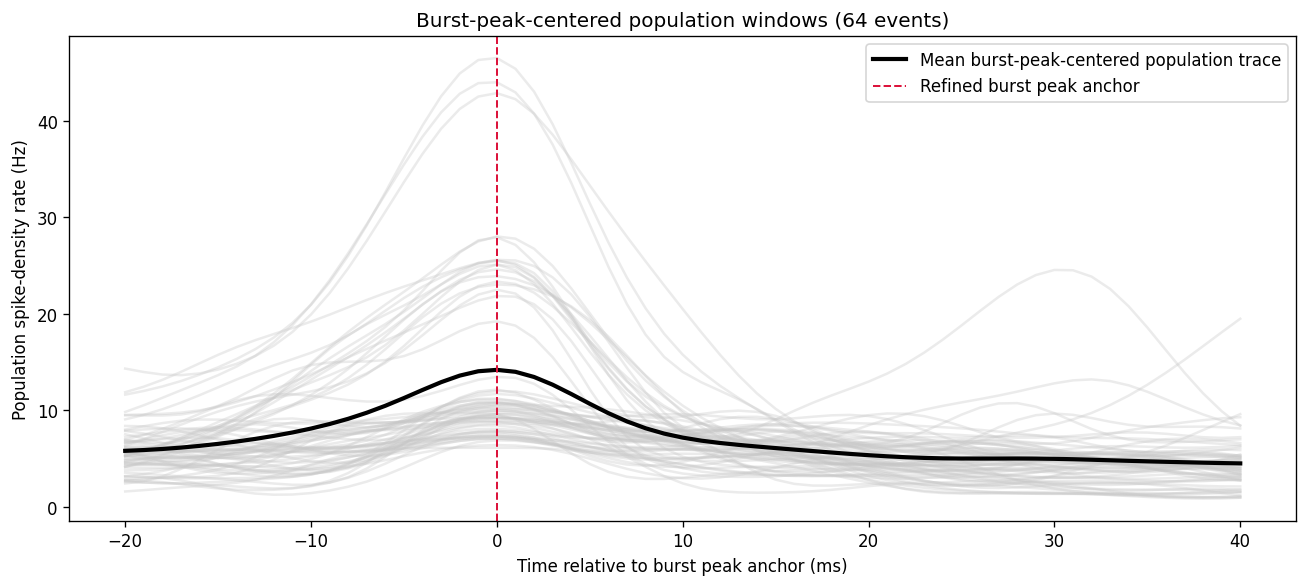

Valid burst-peak-centered windows: 64
Aligned tensor shape: (64, 998, 61)


In [41]:
aligned = align_highres_to_anchors(
    highres,
    analysis_anchors,
    pre_ms=ALIGN_PRE_MS,
    post_ms=ALIGN_POST_MS,
    bin_ms=HIGHRES_BIN_MS,
)

pre_bins = int(round(ALIGN_PRE_MS / HIGHRES_BIN_MS))
post_bins = int(round(ALIGN_POST_MS / HIGHRES_BIN_MS))
relative_time_ms = aligned.relative_time_ms

time_centers_highres = highres.time_centers_s
population_rate_highres = highres.population_rate_hz
per_electrode_rate_highres = highres.per_electrode_rate_hz
selected_electrodes = highres.electrodes
spikes_by_electrode = highres.spikes_by_electrode
spike_presence_highres = highres.spike_presence
population_windows = aligned.population_windows
aligned_tensor = aligned.aligned_rate
aligned_spike_tensor = aligned.aligned_spikes
valid_burst_peak_anchors = pd.DataFrame(aligned.valid_anchors)
valid_nested_anchors = valid_burst_peak_anchors


def select_example_events(anchors_df, count):
    if anchors_df is None or len(anchors_df) == 0:
        return pd.DataFrame()
    count = min(int(count), len(anchors_df))
    if "anchor_height_hz" in anchors_df:
        anchor_heights = anchors_df["anchor_height_hz"].to_numpy(dtype=float)
    elif "anchor_population_rate_hz" in anchors_df:
        anchor_heights = anchors_df["anchor_population_rate_hz"].to_numpy(dtype=float)
    else:
        anchor_heights = np.arange(len(anchors_df), dtype=float)
    sorted_indices = np.argsort(anchor_heights)

    highest_candidates = [int(idx) for idx in sorted_indices[::-1][:2]]
    median_center = len(sorted_indices) // 2
    median_start = max(0, median_center - 1)
    median_stop = min(len(sorted_indices), median_start + 2)
    median_candidates = [int(idx) for idx in sorted_indices[median_start:median_stop]]
    lowest_candidates = [int(idx) for idx in sorted_indices[:2]]

    example_indices = []
    selection_labels = {}
    for band_name, candidates in [("highest", highest_candidates), ("median", median_candidates), ("lowest", lowest_candidates)]:
        for idx in candidates:
            if idx not in example_indices:
                example_indices.append(idx)
                selection_labels[idx] = band_name

    if len(example_indices) < count:
        for idx in sorted_indices[::-1]:
            idx = int(idx)
            if idx not in example_indices:
                example_indices.append(idx)
                selection_labels[idx] = "additional"
            if len(example_indices) >= count:
                break

    example_indices = np.asarray(example_indices[:count], dtype=int)
    out = anchors_df.iloc[example_indices].copy()
    out["window_idx"] = example_indices
    out["selection_band"] = [selection_labels[int(idx)] for idx in example_indices]
    out["selection_band"] = pd.Categorical(
        out["selection_band"],
        categories=["highest", "median", "lowest", "additional"],
        ordered=True,
    )
    if "gamma_peak_rank" not in out:
        out["gamma_peak_rank"] = 0
    sort_cols = [col for col in ["selection_band", "coarse_event_idx", "gamma_peak_rank"] if col in out]
    return out.sort_values(sort_cols).reset_index(drop=True)


example_events = select_example_events(valid_nested_anchors, EXAMPLE_GAMMA_EVENT_COUNT)

fig, ax = plt.subplots(figsize=(11, 5))
for row in population_windows:
    ax.plot(relative_time_ms, row, color="0.78", alpha=0.35)
ax.plot(relative_time_ms, population_windows.mean(axis=0), color="black", lw=2.5, label="Mean burst-peak-centered population trace")
ax.axvline(0.0, color="crimson", ls="--", lw=1.2, label="Refined burst peak anchor")
ax.set_xlabel("Time relative to burst peak anchor (ms)")
ax.set_ylabel("Population spike-density rate (Hz)")
ax.set_title(f"Burst-peak-centered population windows ({len(valid_nested_anchors)} events)")
ax.legend(loc="upper right")
plt.tight_layout()
save_inline_plot(fig, "burst_peak_centered_population_windows")

print(f"Valid burst-peak-centered windows: {len(valid_nested_anchors)}")
print(f"Aligned tensor shape: {aligned_tensor.shape}")


## Signed Eventwise X-Bin Wave-Peak Analysis
Replace the earlier signed-bin TE-like contrast with a simpler eventwise propagation summary. For each burst-peak-centered event, bin electrodes by **signed x-position** relative to the array midpoint, average the per-electrode spike-density traces within each x-bin, and record the **time of peak activity** for each bin relative to the event peak.

This gives a direct macroscopic wave readout: if the average peak time drifts systematically with signed x-position, the fitted slope of `delay vs signed x` yields an implied propagation speed for the wave peak. The plots below show the mean x-binned traces, the eventwise peak-delay cloud with bin-level summaries, and a bootstrap confidence interval for the implied speed.


In [ ]:
if len(valid_nested_anchors) == 0:
    raise ValueError("No valid burst-peak-centered windows are available for signed eventwise wave analysis.")

settings = package_wave_settings_from_config(
    x_bin_um=WAVE_X_BIN_UM,
    peak_search_start_ms=WAVE_PEAK_SEARCH_START_MS,
    peak_search_stop_ms=WAVE_PEAK_SEARCH_STOP_MS,
    trace_smooth_sigma_ms=WAVE_TRACE_SMOOTH_SIGMA_MS,
    bin_ms=HIGHRES_BIN_MS,
    min_electrodes_per_bin=WAVE_MIN_ELECTRODES_PER_BIN,
    min_events_per_bin=WAVE_MIN_EVENTS_PER_BIN,
    bootstrap_reps=WAVE_BOOTSTRAP_REPS,
    random_seed=WAVE_RANDOM_SEED,
)
recording_id = f"stimRemovalNull_well{int(WELL)}_DIV{int(DIV)}"
wave_result = package_compute_or_load_wave_result(
    recording_id,
    aligned,
    rec.layout,
    cache_root=WAVE_CACHE_ROOT,
    force=bool(WAVE_FORCE_RECOMPUTE),
    **settings,
)

wave_event_direction_df = wave_result.event_direction
wave_trace_df = wave_result.trace
wave_peak_df = wave_result.peaks
wave_bin_summary = wave_result.bin_summary
wave_peak_fit_summary = wave_result.fit_summary
wave_heatmap = wave_result.heatmap
wave_boot_speeds = wave_result.bootstrap_speeds

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), constrained_layout=True)
draw_wave_timing_panel(
    wave_result,
    axes[0],
    title="Wave-peak timing on origin-aligned traces",
    show_colorbar=True,
    compact=False,
)
draw_wave_bootstrap_panel(
    wave_result,
    axes[1],
    title="Bootstrap implied speed distribution",
    compact=False,
)
save_inline_plot(fig, "wave_peak_timing_origin_aligned")

print(
    f"Signed eventwise wave analysis: {wave_peak_df['window_idx'].nunique()} reoriented events | "
    f"{len(wave_bin_summary)} populated origin-referenced x-bins | x-bin width={WAVE_X_BIN_UM:.0f} um"
)
display(wave_peak_fit_summary.round(3))
display(wave_bin_summary.round(3))
display(wave_event_direction_df.round(6))


## Aggregate Signed Eventwise X-Bin Wave-Peak Analysis Across Wells
Compute or load one cached wave result per requested well and DIV, then pool eventwise wave peaks across recordings for an aggregate propagation figure.


In [ ]:
settings = package_wave_settings_from_config(
    x_bin_um=WAVE_X_BIN_UM,
    peak_search_start_ms=WAVE_PEAK_SEARCH_START_MS,
    peak_search_stop_ms=WAVE_PEAK_SEARCH_STOP_MS,
    trace_smooth_sigma_ms=WAVE_TRACE_SMOOTH_SIGMA_MS,
    bin_ms=HIGHRES_BIN_MS,
    min_electrodes_per_bin=WAVE_MIN_ELECTRODES_PER_BIN,
    min_events_per_bin=WAVE_MIN_EVENTS_PER_BIN,
    bootstrap_reps=WAVE_BOOTSTRAP_REPS,
    random_seed=WAVE_RANDOM_SEED,
)

aggregate_wave_results_by_recording = []
aggregate_wave_rows = []
aggregate_prep_cfg = PrepConfig(mode="top", top_start=TOP_START, top_stop=TOP_STOP, verbose=False)

for spec_i in iter_aggregate_recording_specs():
    recording_id_i = spec_i["recording_id"]
    cached_i = None if bool(WAVE_FORCE_RECOMPUTE) else package_load_wave_result_cache(
        package_wave_cache_dir(WAVE_CACHE_ROOT, recording_id_i, **settings)
    )
    if cached_i is None:
        ds_i = load_recording_from_spec(spec_i)
        rec_i = ds_i.recordings[0]
        refs_i = ds_i.select_ref_electrodes(aggregate_prep_cfg)[0]
        aligned_i, intermediates_i = package_build_burst_peak_aligned_events(
            rec_i,
            refs_i,
            ifr_grid_hz=IFR_GRID_HZ,
            smooth_sigma_sec=SMOOTH_SIGMA_SEC,
            highres_bin_ms=HIGHRES_BIN_MS,
            highres_smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
            network_bin_ms=NETWORK_BIN_MS,
            high_activity_mad_scale=HIGH_ACTIVITY_MAD_SCALE,
            high_activity_min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
            high_activity_max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
            network_min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
            network_min_duration_ms=NETWORK_MIN_DURATION_MS,
            align_pre_ms=ALIGN_PRE_MS,
            align_post_ms=ALIGN_POST_MS,
        )
        if len(pd.DataFrame(aligned_i.valid_anchors)) == 0:
            print(f"Skipping {recording_id_i}: no valid aligned burst anchors")
            continue
        result_i = package_compute_or_load_wave_result(
            recording_id_i,
            aligned_i,
            rec_i.layout,
            cache_root=WAVE_CACHE_ROOT,
            force=bool(WAVE_FORCE_RECOMPUTE),
            **settings,
        )
        n_refs_i = int(len(refs_i))
        n_bursts_i = int(len(intermediates_i["burst_epochs"]))
    else:
        print(f"Loaded cached wave result: {package_wave_cache_dir(WAVE_CACHE_ROOT, recording_id_i, **settings)}")
        result_i = cached_i
        n_refs_i = np.nan
        n_bursts_i = int(result_i.fit_summary.iloc[0]["n_events_used"])

    aggregate_wave_results_by_recording.append((recording_id_i, result_i))
    row_i = package_summarize_wave_recording_result(
        recording_id_i,
        well=int(spec_i["well"]),
        div=int(spec_i.get("div", DIV)),
        result=result_i,
        settings=settings,
        n_refs=n_refs_i,
        n_bursts=n_bursts_i,
    )
    row_i.update({"dataset": spec_i["dataset"], "source_file": spec_i["source_file"]})
    aggregate_wave_rows.append(row_i)

if not aggregate_wave_results_by_recording:
    raise ValueError("No aggregate wave results were available. Check AGGREGATE_WELLS and AGGREGATE_DIVS.")

aggregate_recording_id = f"aggregate_{DATASET}_wells{'-'.join(map(str, AGGREGATE_WELLS))}"
if DATASET == "stim_removal_null":
    aggregate_recording_id += f"_DIVs{'-'.join(map(str, AGGREGATE_DIVS))}"
aggregate_cache_dir = package_wave_cache_dir(WAVE_CACHE_ROOT, aggregate_recording_id, **settings)
aggregate_wave_result = None if bool(AGGREGATE_WAVE_FORCE_RECOMPUTE) else package_load_wave_result_cache(aggregate_cache_dir)
aggregate_wave_per_recording_fit = None
if aggregate_wave_result is None:
    aggregate_wave_result, aggregate_wave_per_recording_fit = package_aggregate_wave_results(
        aggregate_wave_results_by_recording,
        x_bin_um=WAVE_X_BIN_UM,
        min_events_per_bin=WAVE_MIN_EVENTS_PER_BIN,
        bootstrap_reps=WAVE_BOOTSTRAP_REPS,
        random_seed=WAVE_RANDOM_SEED,
    )
    package_save_wave_result_cache(aggregate_wave_result, aggregate_cache_dir)
    print(f"Saved aggregate wave result cache: {aggregate_cache_dir}")
else:
    print(f"Loaded cached aggregate wave result: {aggregate_cache_dir}")

aggregate_wave_summary = pd.DataFrame(aggregate_wave_rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), constrained_layout=True)
draw_wave_timing_panel(
    aggregate_wave_result,
    axes[0],
    title=f"Aggregate {DATASET} wells | wave-peak timing",
    show_colorbar=True,
    compact=False,
)
draw_wave_bootstrap_panel(
    aggregate_wave_result,
    axes[1],
    title=f"Aggregate {DATASET} wells | bootstrap speed",
    compact=False,
)
save_inline_plot(fig, f"aggregate_{DATASET}_wave_peak_timing_origin_aligned")
display(aggregate_wave_result.fit_summary.round(3))
display(aggregate_wave_summary.round(3))
display(aggregate_wave_result.bin_summary.round(3))

## Transfer Entropy
Transfer-entropy analyses are kept out of this burst notebook. Use `Notebooks/stimRemovalNull_transferEntropy.ipynb` for TE-specific configuration, execution, and plots.


## Example Burst-Anchor-Centered IFR Time Series
Inspect individual event windows centered on the max high-resolution population IFR anchor. The left column shows the same high-resolution population trace used for anchor selection.


## Example Event Hex-Tiled GIFs
Use the same event selection as the example burst-peak-centered IFR section, but render each event as its own hex-tiled propagation GIF. The frame timing, hex-grid size, and log-scale rendering match the later average-array GIF section. GIF saving is optional; when disabled, preview files are written to a temporary directory for display only.


In [ ]:
example_hex_dir = (repo_root / EXAMPLE_EVENT_HEX_DIR) if EXAMPLE_EVENT_HEX_SAVE else (Path("/tmp") / "ephax_example_event_hex")
example_hex_dir.mkdir(parents=True, exist_ok=True)
example_xlim = (ARRAY_X_MIN_UM, ARRAY_X_MAX_UM)
example_ylim = (ARRAY_Y_MIN_UM, ARRAY_Y_MAX_UM)

example_event_gif_paths = []
for row in example_events.itertuples(index=False):
    window_idx = int(row.window_idx)
    if window_idx < 0 or window_idx >= len(aligned.aligned_rate):
        continue
    band_label = str(row.selection_band)
    gif_name = f"well{WELL}_DIV{DIV}_event{int(row.coarse_event_idx)}_{band_label}.gif"
    gif_path = example_hex_dir / gif_name
    save_event_hex_gif(
        aligned,
        rec.layout,
        window_idx,
        gif_path,
        title=f"{band_label.title()} example | event {int(row.coarse_event_idx)}",
        frame_step_ms=GIF_FRAME_STEP_MS,
        bin_ms=HIGHRES_BIN_MS,
        gridsize=HEX_GRID_SIZE,
        xlim=example_xlim,
        ylim=example_ylim,
        scale_values=aligned.aligned_rate,
        duration=0.14,
        dpi=140,
    )
    example_event_gif_paths.append((band_label, int(row.coarse_event_idx), int(row.gamma_peak_rank), gif_path))

for band_label, coarse_event_idx, gamma_peak_rank, gif_path in example_event_gif_paths:
    print(f"{band_label.title()} example | event {coarse_event_idx} | gamma {gamma_peak_rank}: {gif_path}")
    display(Image(filename=str(gif_path)))


## Example Event Temporal-Order HD-MEA Maps

Paper-ready static replacement for the GIF previews above. Each electrode is plotted at its physical HD-MEA coordinate and colored by the time of its peak spike-density rate relative to the gamma anchor. The aggregate panel uses the mean aligned electrode rate across all valid events; the remaining panels use the same individual events selected for the GIFs.


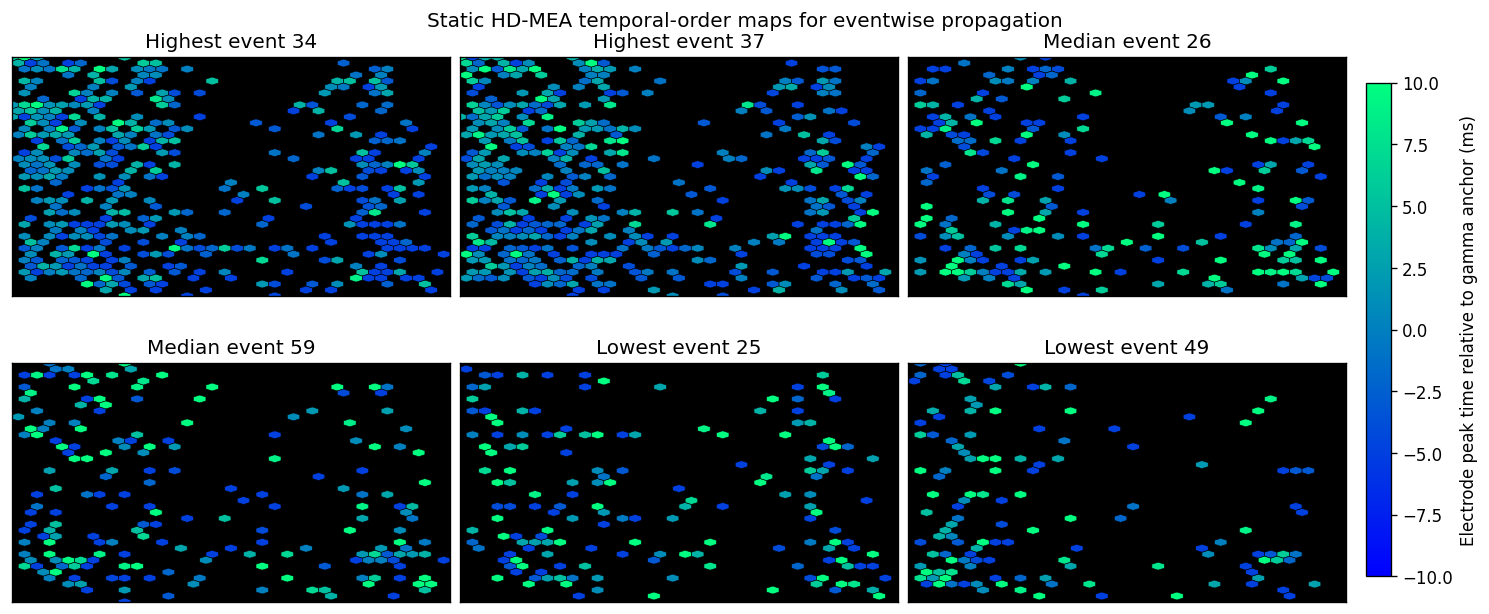

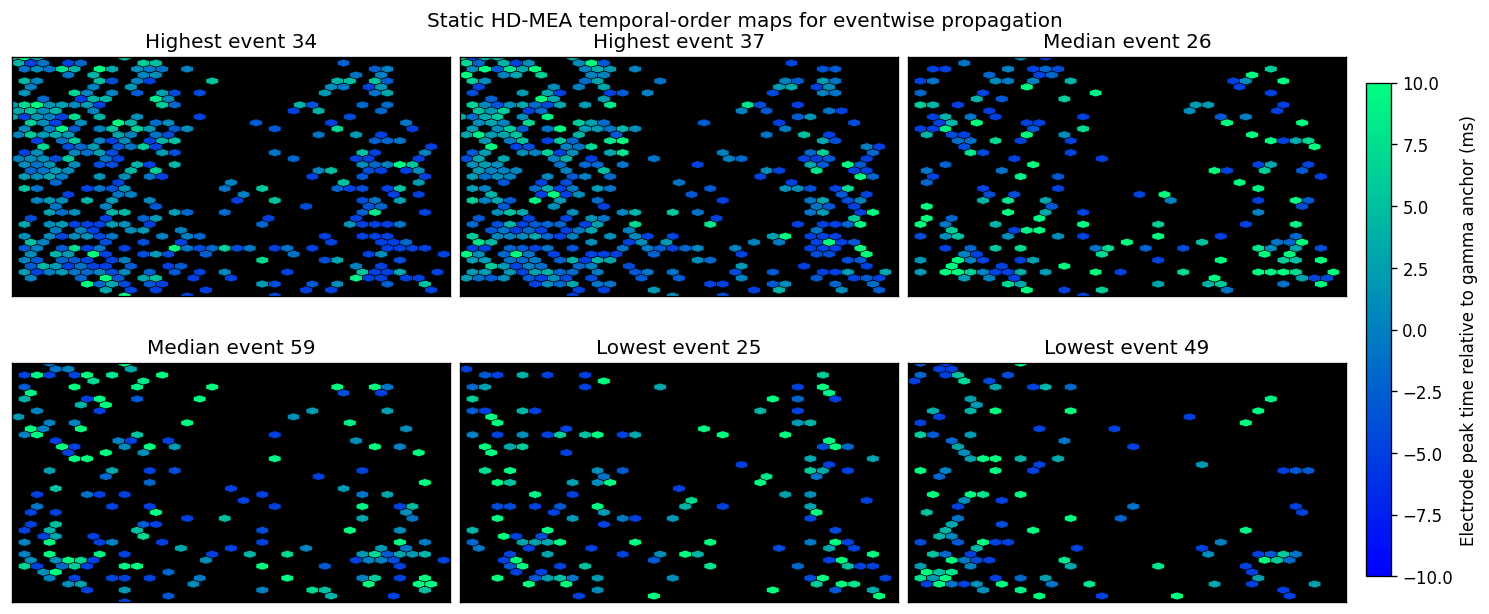

In [45]:
temporal_order_peak_start_ms = -float(SORT_PEAK_PRE_MS)
temporal_order_peak_stop_ms = float(SORT_PEAK_POST_MS)
temporal_order_color_limit_ms = max(abs(temporal_order_peak_start_ms), abs(temporal_order_peak_stop_ms))

example_peak_time_maps = []
for row in example_events.itertuples(index=False):
    window_idx = int(row.window_idx)
    if window_idx < 0 or window_idx >= len(aligned_tensor):
        continue
    band_label = str(row.selection_band)
    peak_map = compute_electrode_peak_time_map(
        aligned,
        rec.layout,
        window_idx=window_idx,
        peak_search_start_ms=temporal_order_peak_start_ms,
        peak_search_stop_ms=temporal_order_peak_stop_ms,
    )
    title = f"{band_label.title()} event {int(row.coarse_event_idx)}"
    example_peak_time_maps.append((title, peak_map))

map_panels = example_peak_time_maps
ncols = min(3, max(1, len(map_panels)))
nrows = int(np.ceil(len(map_panels) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.1 * ncols, 2.55 * nrows), constrained_layout=True)
axes = np.atleast_1d(axes).reshape(-1)

for ax, (title, peak_map) in zip(axes, map_panels):
    draw_electrode_peak_time_map(
        peak_map,
        ax,
        title=title,
        cmap="winter",
        vmin=-temporal_order_color_limit_ms,
        vmax=temporal_order_color_limit_ms,
        show_colorbar=False,
        render_mode="hexbin",
        gridsize=HEX_GRID_SIZE,
        compact=True,
        xlim=example_xlim,
        ylim=example_ylim,
        marker_size=4.0 if DATASET == "stim_removal_null" else 8.0,
    )
for ax in axes[len(map_panels):]:
    ax.axis("off")

sm = plt.cm.ScalarMappable(
    norm=Normalize(vmin=-temporal_order_color_limit_ms, vmax=temporal_order_color_limit_ms),
    cmap="winter",
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:len(map_panels)], shrink=0.82, pad=0.015)
cbar.set_label("Electrode peak time relative to gamma anchor (ms)")
fig.suptitle("Static HD-MEA temporal-order maps for eventwise propagation", y=1.02)
save_inline_plot(fig, "example_event_temporal_order_hdmea_maps")


## Gamma-Centered Propagation Summary

Average the high-resolution, per-electrode spike-density traces across all valid nested anchors and sort electrodes by how strongly they fire around the burst peak. This pushes the most active, most rhythmically re-firing electrodes to the top of the view.


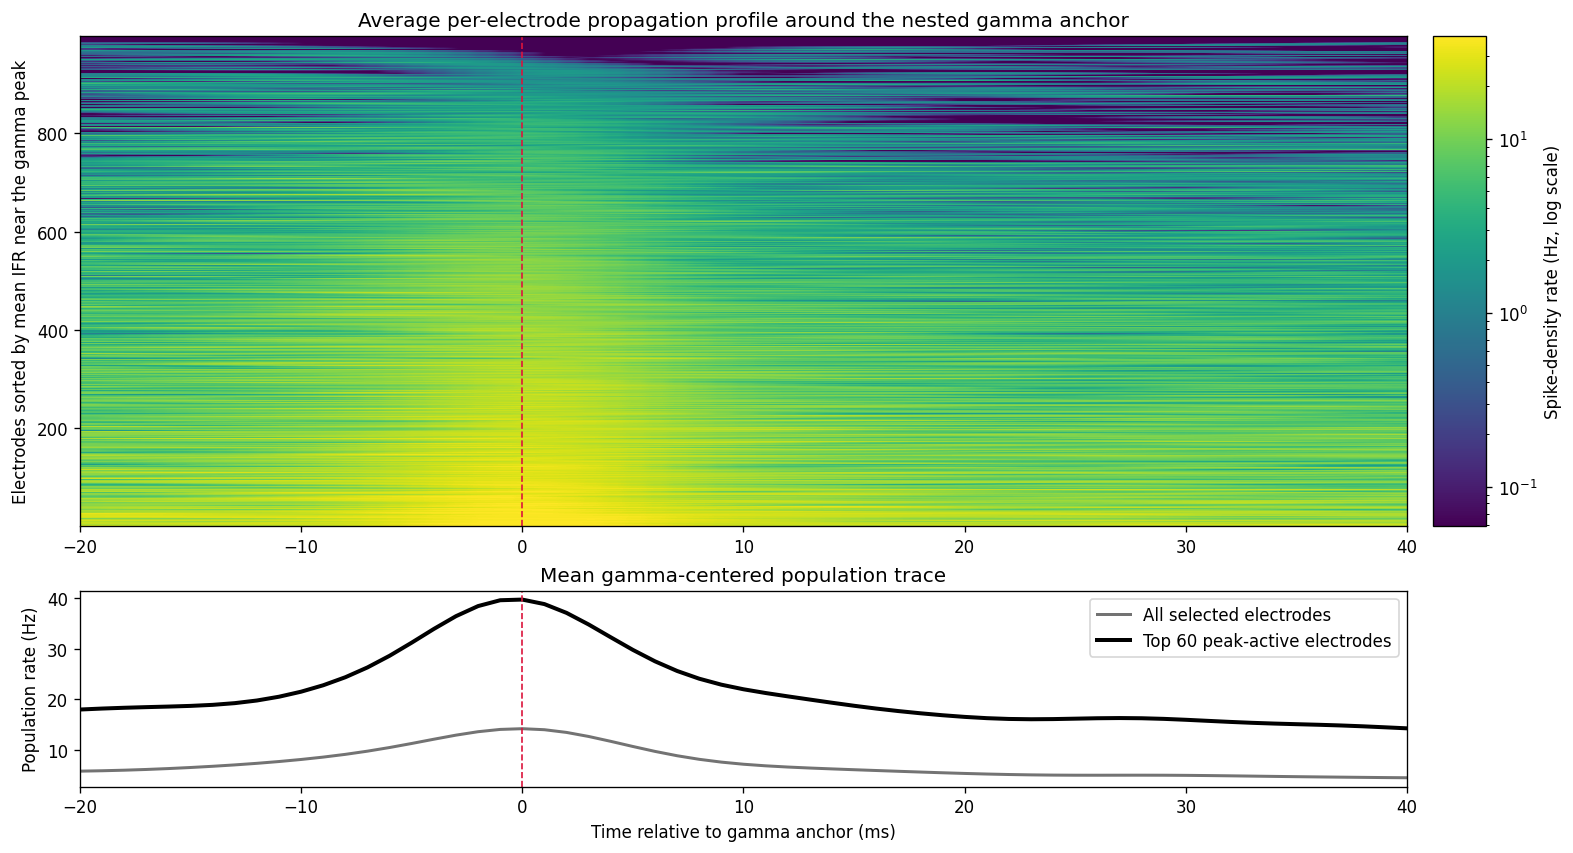

,electrode,window_mean_hz,peak_window_mean_hz,rebound_window_mean_hz,anchor_rate_hz,max_rate_hz
0,17901,26.040862,44.988640,16.943665,58.273668,58.273668
1,24059,26.753220,39.674809,23.740596,54.915742,54.915742
2,18423,23.389148,38.243360,18.998776,49.302928,51.093411
3,4657,32.294414,38.038560,25.815737,50.818547,54.014045
4,17843,25.770967,37.892592,19.936020,46.520860,46.520860
5,3769,23.488979,36.848019,16.490304,54.928976,56.789497
6,16529,33.691111,36.722588,29.552684,48.622174,51.964396
7,23553,18.506778,36.171692,12.785187,41.543364,42.115705
8,6829,22.987814,35.392358,16.183972,43.930327,44.731375
9,18289,21.024906,35.302682,12.007551,40.833883,42.340386


In [46]:
mean_aligned_electrode_rate = aligned_tensor.mean(axis=0)
peak_window_mask = (relative_time_ms >= -SORT_PEAK_PRE_MS) & (relative_time_ms <= SORT_PEAK_POST_MS)
rebound_window_mask = (relative_time_ms >= 15.0) & (relative_time_ms <= 25.0)

rate_summary = pd.DataFrame(
    {
        "electrode": selected_electrodes.astype(int),
        "window_mean_hz": mean_aligned_electrode_rate.mean(axis=1),
        "peak_window_mean_hz": mean_aligned_electrode_rate[:, peak_window_mask].mean(axis=1),
        "rebound_window_mean_hz": mean_aligned_electrode_rate[:, rebound_window_mask].mean(axis=1),
        "anchor_rate_hz": mean_aligned_electrode_rate[:, relative_time_ms == 0.0].reshape(-1),
        "max_rate_hz": mean_aligned_electrode_rate.max(axis=1),
    }
).sort_values(
    ["peak_window_mean_hz", "rebound_window_mean_hz", "max_rate_hz", "electrode"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

ordered_electrodes = rate_summary["electrode"].to_numpy(dtype=int)
ordered_idx = np.array([np.flatnonzero(selected_electrodes == int(el))[0] for el in ordered_electrodes], dtype=int)
ordered_aligned_rate = mean_aligned_electrode_rate[ordered_idx]
top_active_count = min(60, max(10, ordered_aligned_rate.shape[0] // 10))
top_active_trace = ordered_aligned_rate[:top_active_count].mean(axis=0)

positive_aligned = ordered_aligned_rate[ordered_aligned_rate > 0]
aligned_vmin = max(1e-2, float(np.quantile(positive_aligned, 0.05)))
aligned_vmax = max(aligned_vmin * 10.0, float(np.quantile(positive_aligned, 0.995)))

fig = plt.figure(figsize=(13, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[3.0, 1.2], width_ratios=[40.0, 1.6])
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
cax = fig.add_subplot(gs[0, 1])
fig.add_subplot(gs[1, 1]).axis("off")

im = ax0.imshow(
    np.clip(ordered_aligned_rate, aligned_vmin, aligned_vmax),
    aspect="auto",
    origin="lower",
    extent=[relative_time_ms[0], relative_time_ms[-1], 0.5, ordered_aligned_rate.shape[0] + 0.5],
    cmap="viridis",
    norm=LogNorm(vmin=aligned_vmin, vmax=aligned_vmax),
)
ax0.axvline(0.0, color="crimson", ls="--", lw=1.0)
ax0.set_ylabel("Electrodes sorted by mean IFR near the gamma peak")
ax0.set_title("Average per-electrode propagation profile around the nested gamma anchor")

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Spike-density rate (Hz, log scale)")
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatterMathtext(base=10)
cbar.update_ticks()

ax1.plot(relative_time_ms, population_windows.mean(axis=0), color="0.45", lw=1.8, label="All selected electrodes")
ax1.plot(relative_time_ms, top_active_trace, color="black", lw=2.4, label=f"Top {top_active_count} peak-active electrodes")
ax1.axvline(0.0, color="crimson", ls="--", lw=1.0)
ax1.set_xlabel("Time relative to gamma anchor (ms)")
ax1.set_ylabel("Population rate (Hz)")
ax1.set_title("Mean gamma-centered population trace")
ax1.legend(loc="upper right")
save_inline_plot(fig, "average_per_electrode_propagation_peak_activity_sorted")

rate_summary.head(20)


## Peak-Time Ordered Propagation View

Sort electrodes by the timepoint of their own maximal mean IFR relative to the refined burst peak anchor. This emphasizes ordering by when each electrode peaks, rather than by how strongly it fires.


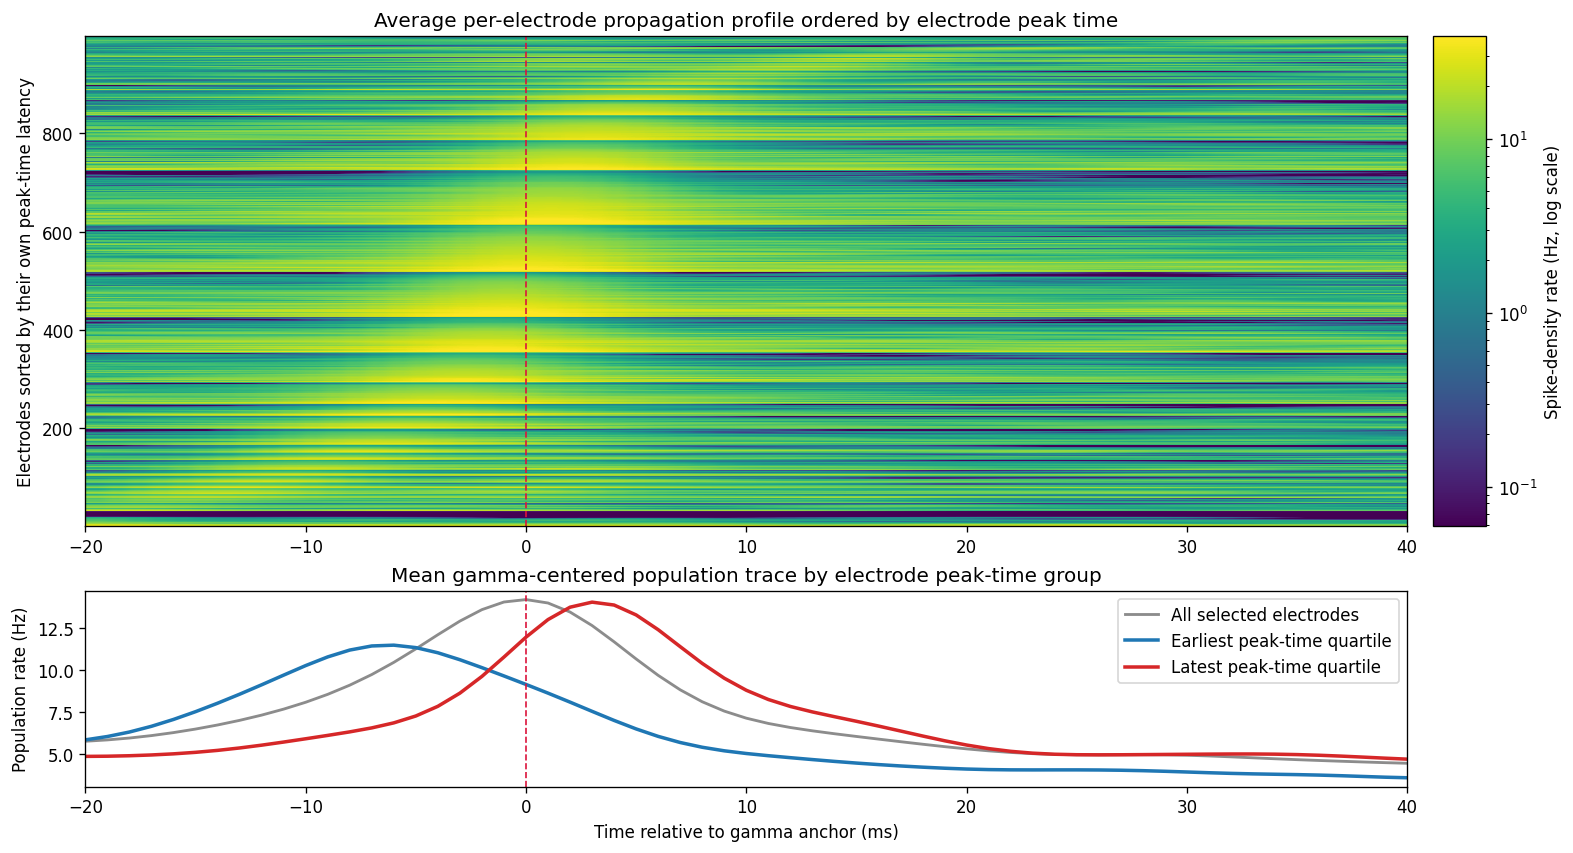

,electrode,peak_time_ms,peak_rate_hz,peak_window_mean_hz,rebound_window_mean_hz
0,6429,-20.0,36.561873,33.229906,24.963959
1,11695,-20.0,29.929928,21.578551,16.690032
2,2051,-20.0,27.488714,16.909962,21.209962
3,19203,-20.0,26.573840,13.312451,13.322065
4,5649,-20.0,16.408438,11.101692,10.518442
5,18861,-20.0,12.390401,7.825509,2.526940
6,6589,-20.0,11.411018,5.171692,4.341436
7,5233,-20.0,11.008413,4.825997,0.176773
8,7027,-20.0,10.154961,1.269261,1.691592
9,2023,-20.0,7.155084,3.698800,0.177496


In [47]:
peak_time_idx = np.argmax(mean_aligned_electrode_rate, axis=1)
peak_time_summary = rate_summary.merge(
    pd.DataFrame(
        {
            "electrode": selected_electrodes.astype(int),
            "peak_time_ms": relative_time_ms[peak_time_idx],
            "peak_rate_hz": mean_aligned_electrode_rate[np.arange(mean_aligned_electrode_rate.shape[0]), peak_time_idx],
        }
    ),
    on="electrode",
    how="left",
).sort_values(
    ["peak_time_ms", "peak_rate_hz", "peak_window_mean_hz", "electrode"],
    ascending=[True, False, False, True],
).reset_index(drop=True)

peak_time_electrodes = peak_time_summary["electrode"].to_numpy(dtype=int)
peak_time_order_idx = np.array([np.flatnonzero(selected_electrodes == int(el))[0] for el in peak_time_electrodes], dtype=int)
peak_time_ordered_rate = mean_aligned_electrode_rate[peak_time_order_idx]

early_cutoff = float(peak_time_summary["peak_time_ms"].quantile(0.25))
late_cutoff = float(peak_time_summary["peak_time_ms"].quantile(0.75))
early_trace = peak_time_ordered_rate[peak_time_summary["peak_time_ms"].to_numpy() <= early_cutoff].mean(axis=0)
late_trace = peak_time_ordered_rate[peak_time_summary["peak_time_ms"].to_numpy() >= late_cutoff].mean(axis=0)

peak_time_positive = peak_time_ordered_rate[peak_time_ordered_rate > 0]
peak_time_vmin = max(1e-2, float(np.quantile(peak_time_positive, 0.05)))
peak_time_vmax = max(peak_time_vmin * 10.0, float(np.quantile(peak_time_positive, 0.995)))

fig = plt.figure(figsize=(13, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[3.0, 1.2], width_ratios=[40.0, 1.6])
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
cax = fig.add_subplot(gs[0, 1])
fig.add_subplot(gs[1, 1]).axis("off")

im = ax0.imshow(
    np.clip(peak_time_ordered_rate, peak_time_vmin, peak_time_vmax),
    aspect="auto",
    origin="lower",
    extent=[relative_time_ms[0], relative_time_ms[-1], 0.5, peak_time_ordered_rate.shape[0] + 0.5],
    cmap="viridis",
    norm=LogNorm(vmin=peak_time_vmin, vmax=peak_time_vmax),
)
ax0.axvline(0.0, color="crimson", ls="--", lw=1.0)
ax0.set_ylabel("Electrodes sorted by their own peak-time latency")
ax0.set_title("Average per-electrode propagation profile ordered by electrode peak time")

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Spike-density rate (Hz, log scale)")
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatterMathtext(base=10)
cbar.update_ticks()

ax1.plot(relative_time_ms, population_windows.mean(axis=0), color="0.55", lw=1.7, label="All selected electrodes")
ax1.plot(relative_time_ms, early_trace, color="#1f77b4", lw=2.1, label="Earliest peak-time quartile")
ax1.plot(relative_time_ms, late_trace, color="#d62728", lw=2.1, label="Latest peak-time quartile")
ax1.axvline(0.0, color="crimson", ls="--", lw=1.0)
ax1.set_xlabel("Time relative to gamma anchor (ms)")
ax1.set_ylabel("Population rate (Hz)")
ax1.set_title("Mean gamma-centered population trace by electrode peak-time group")
ax1.legend(loc="upper right")
save_inline_plot(fig, "average_per_electrode_propagation_peak_time_sorted")

peak_time_summary[["electrode", "peak_time_ms", "peak_rate_hz", "peak_window_mean_hz", "rebound_window_mean_hz"]].head(20)


## Ordering Correlation

Compare each electrode's rank under the activity-based ordering and the peak-time ordering. If the two orderings track each other, points should cluster near the diagonal.


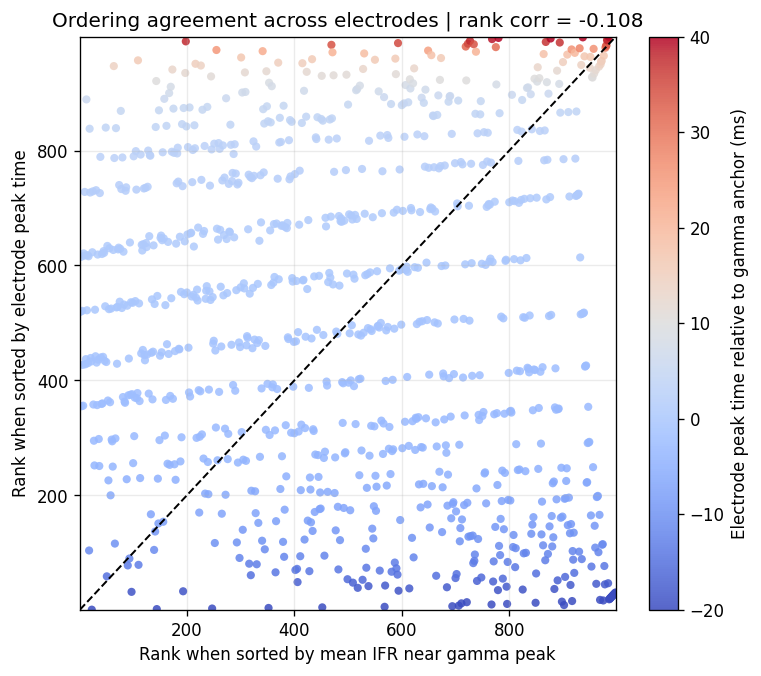

,electrode,peak_activity_rank,peak_time_ms,peak_rate_hz,peak_time_rank
0,17901,1,0.0,58.273668,519
1,24059,2,0.0,54.915742,520
2,18423,3,1.0,51.093411,615
3,4657,4,-2.0,54.014045,355
4,17843,5,0.0,46.520860,521
5,3769,6,-1.0,56.789497,427
6,16529,7,-2.0,51.964396,356
7,23553,8,1.0,42.115705,621
8,6829,9,1.0,44.731375,617
9,18289,10,2.0,42.340386,728


In [48]:
activity_rank = rate_summary[["electrode"]].copy()
activity_rank["peak_activity_rank"] = np.arange(1, len(activity_rank) + 1, dtype=int)

peak_time_rank = peak_time_summary[["electrode", "peak_time_ms", "peak_rate_hz"]].copy()
peak_time_rank["peak_time_rank"] = np.arange(1, len(peak_time_rank) + 1, dtype=int)

ordering_compare = activity_rank.merge(peak_time_rank, on="electrode", how="inner")
rank_corr = float(np.corrcoef(ordering_compare["peak_activity_rank"], ordering_compare["peak_time_rank"])[0, 1])

fig, ax = plt.subplots(figsize=(7.2, 6.2))
scatter = ax.scatter(
    ordering_compare["peak_activity_rank"],
    ordering_compare["peak_time_rank"],
    c=ordering_compare["peak_time_ms"],
    s=24,
    cmap="coolwarm",
    alpha=0.85,
    edgecolors="none",
)
rank_min = 1
rank_max = len(ordering_compare)
ax.plot([rank_min, rank_max], [rank_min, rank_max], color="black", ls="--", lw=1.2)
ax.set_xlim(rank_min, rank_max)
ax.set_ylim(rank_min, rank_max)
ax.set_xlabel("Rank when sorted by mean IFR near gamma peak")
ax.set_ylabel("Rank when sorted by electrode peak time")
ax.set_title(f"Ordering agreement across electrodes | rank corr = {rank_corr:.3f}")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Electrode peak time relative to gamma anchor (ms)")
ax.grid(True, alpha=0.25)
save_inline_plot(fig, "electrode_ordering_rank_comparison")

ordering_compare.sort_values("peak_activity_rank").head(20)


## X-Ordered Propagation View

Sort electrodes by their physical `x` position on the array to test the left-to-right propagation hypothesis directly.


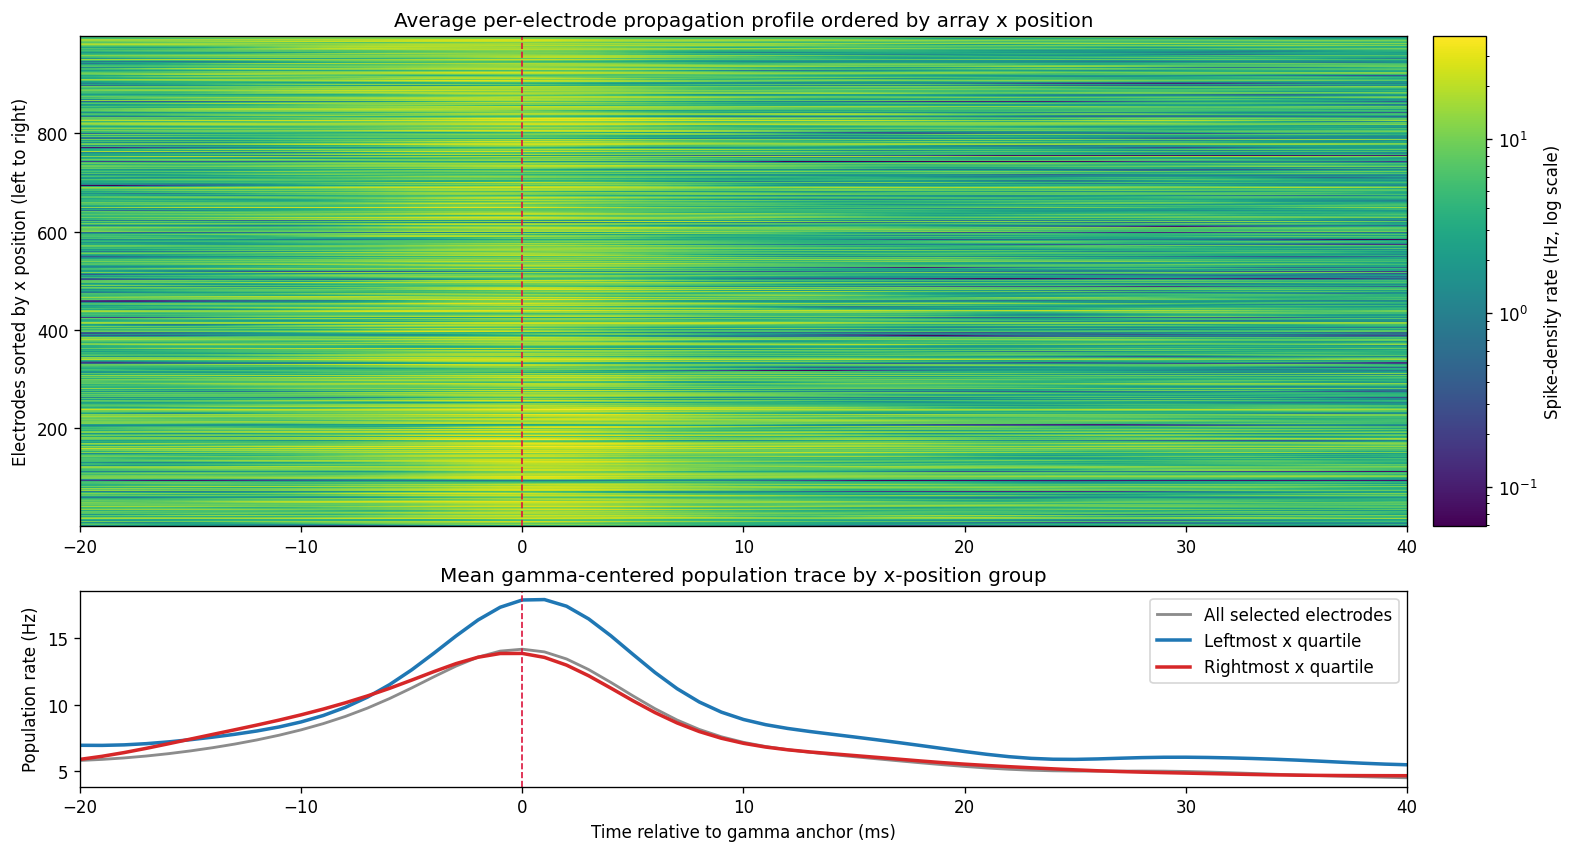

,electrode,x,y,peak_window_mean_hz,rebound_window_mean_hz
0,5061.0,17.5,402.5,3.638313,0.979550
1,20461.0,17.5,1627.5,2.304081,0.171320
2,15183.0,52.5,1207.5,8.094851,3.069247
3,17823.0,52.5,1417.5,9.902858,4.372936
4,20023.0,52.5,1592.5,6.192332,1.958406
5,21343.0,52.5,1697.5,4.639513,2.123013
6,26183.0,52.5,2082.5,15.118372,1.696350
7,1985.0,87.5,157.5,3.149794,0.000000
8,2865.0,87.5,227.5,15.972617,3.836877
9,3745.0,87.5,297.5,25.144556,11.776981


In [49]:
layout_df = pd.DataFrame(rec.layout)
layout_df = layout_df[layout_df["electrode"].isin(selected_electrodes)].drop_duplicates("electrode").copy()
layout_df = layout_df.merge(rate_summary, on="electrode", how="left")

x_sorted_layout = layout_df.sort_values(["x", "y", "peak_window_mean_hz", "electrode"], ascending=[True, True, False, True]).reset_index(drop=True)
x_sorted_electrodes = x_sorted_layout["electrode"].to_numpy(dtype=int)
x_sorted_idx = np.array([np.flatnonzero(selected_electrodes == int(el))[0] for el in x_sorted_electrodes], dtype=int)
x_sorted_rate = mean_aligned_electrode_rate[x_sorted_idx]

left_mask = x_sorted_layout["x"] <= x_sorted_layout["x"].quantile(0.25)
right_mask = x_sorted_layout["x"] >= x_sorted_layout["x"].quantile(0.75)
left_trace = x_sorted_rate[left_mask.to_numpy()].mean(axis=0)
right_trace = x_sorted_rate[right_mask.to_numpy()].mean(axis=0)

x_positive = x_sorted_rate[x_sorted_rate > 0]
x_vmin = max(1e-2, float(np.quantile(x_positive, 0.05)))
x_vmax = max(x_vmin * 10.0, float(np.quantile(x_positive, 0.995)))

fig = plt.figure(figsize=(13, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[3.0, 1.2], width_ratios=[40.0, 1.6])
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
cax = fig.add_subplot(gs[0, 1])
fig.add_subplot(gs[1, 1]).axis("off")

im = ax0.imshow(
    np.clip(x_sorted_rate, x_vmin, x_vmax),
    aspect="auto",
    origin="lower",
    extent=[relative_time_ms[0], relative_time_ms[-1], 0.5, x_sorted_rate.shape[0] + 0.5],
    cmap="viridis",
    norm=LogNorm(vmin=x_vmin, vmax=x_vmax),
)
ax0.axvline(0.0, color="crimson", ls="--", lw=1.0)
ax0.set_ylabel("Electrodes sorted by x position (left to right)")
ax0.set_title("Average per-electrode propagation profile ordered by array x position")

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Spike-density rate (Hz, log scale)")
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatterMathtext(base=10)
cbar.update_ticks()

ax1.plot(relative_time_ms, population_windows.mean(axis=0), color="0.55", lw=1.7, label="All selected electrodes")
ax1.plot(relative_time_ms, left_trace, color="#1f77b4", lw=2.1, label="Leftmost x quartile")
ax1.plot(relative_time_ms, right_trace, color="#d62728", lw=2.1, label="Rightmost x quartile")
ax1.axvline(0.0, color="crimson", ls="--", lw=1.0)
ax1.set_xlabel("Time relative to gamma anchor (ms)")
ax1.set_ylabel("Population rate (Hz)")
ax1.set_title("Mean gamma-centered population trace by x-position group")
ax1.legend(loc="upper right")
save_inline_plot(fig, "average_per_electrode_propagation_x_sorted")

x_sorted_layout[["electrode", "x", "y", "peak_window_mean_hz", "rebound_window_mean_hz"]].head(20)


## Example Burst-Anchor-Centered IFR Time Series
Inspect individual event windows centered on the max high-resolution population IFR anchor. The left column shows the same high-resolution population trace used for anchor selection.


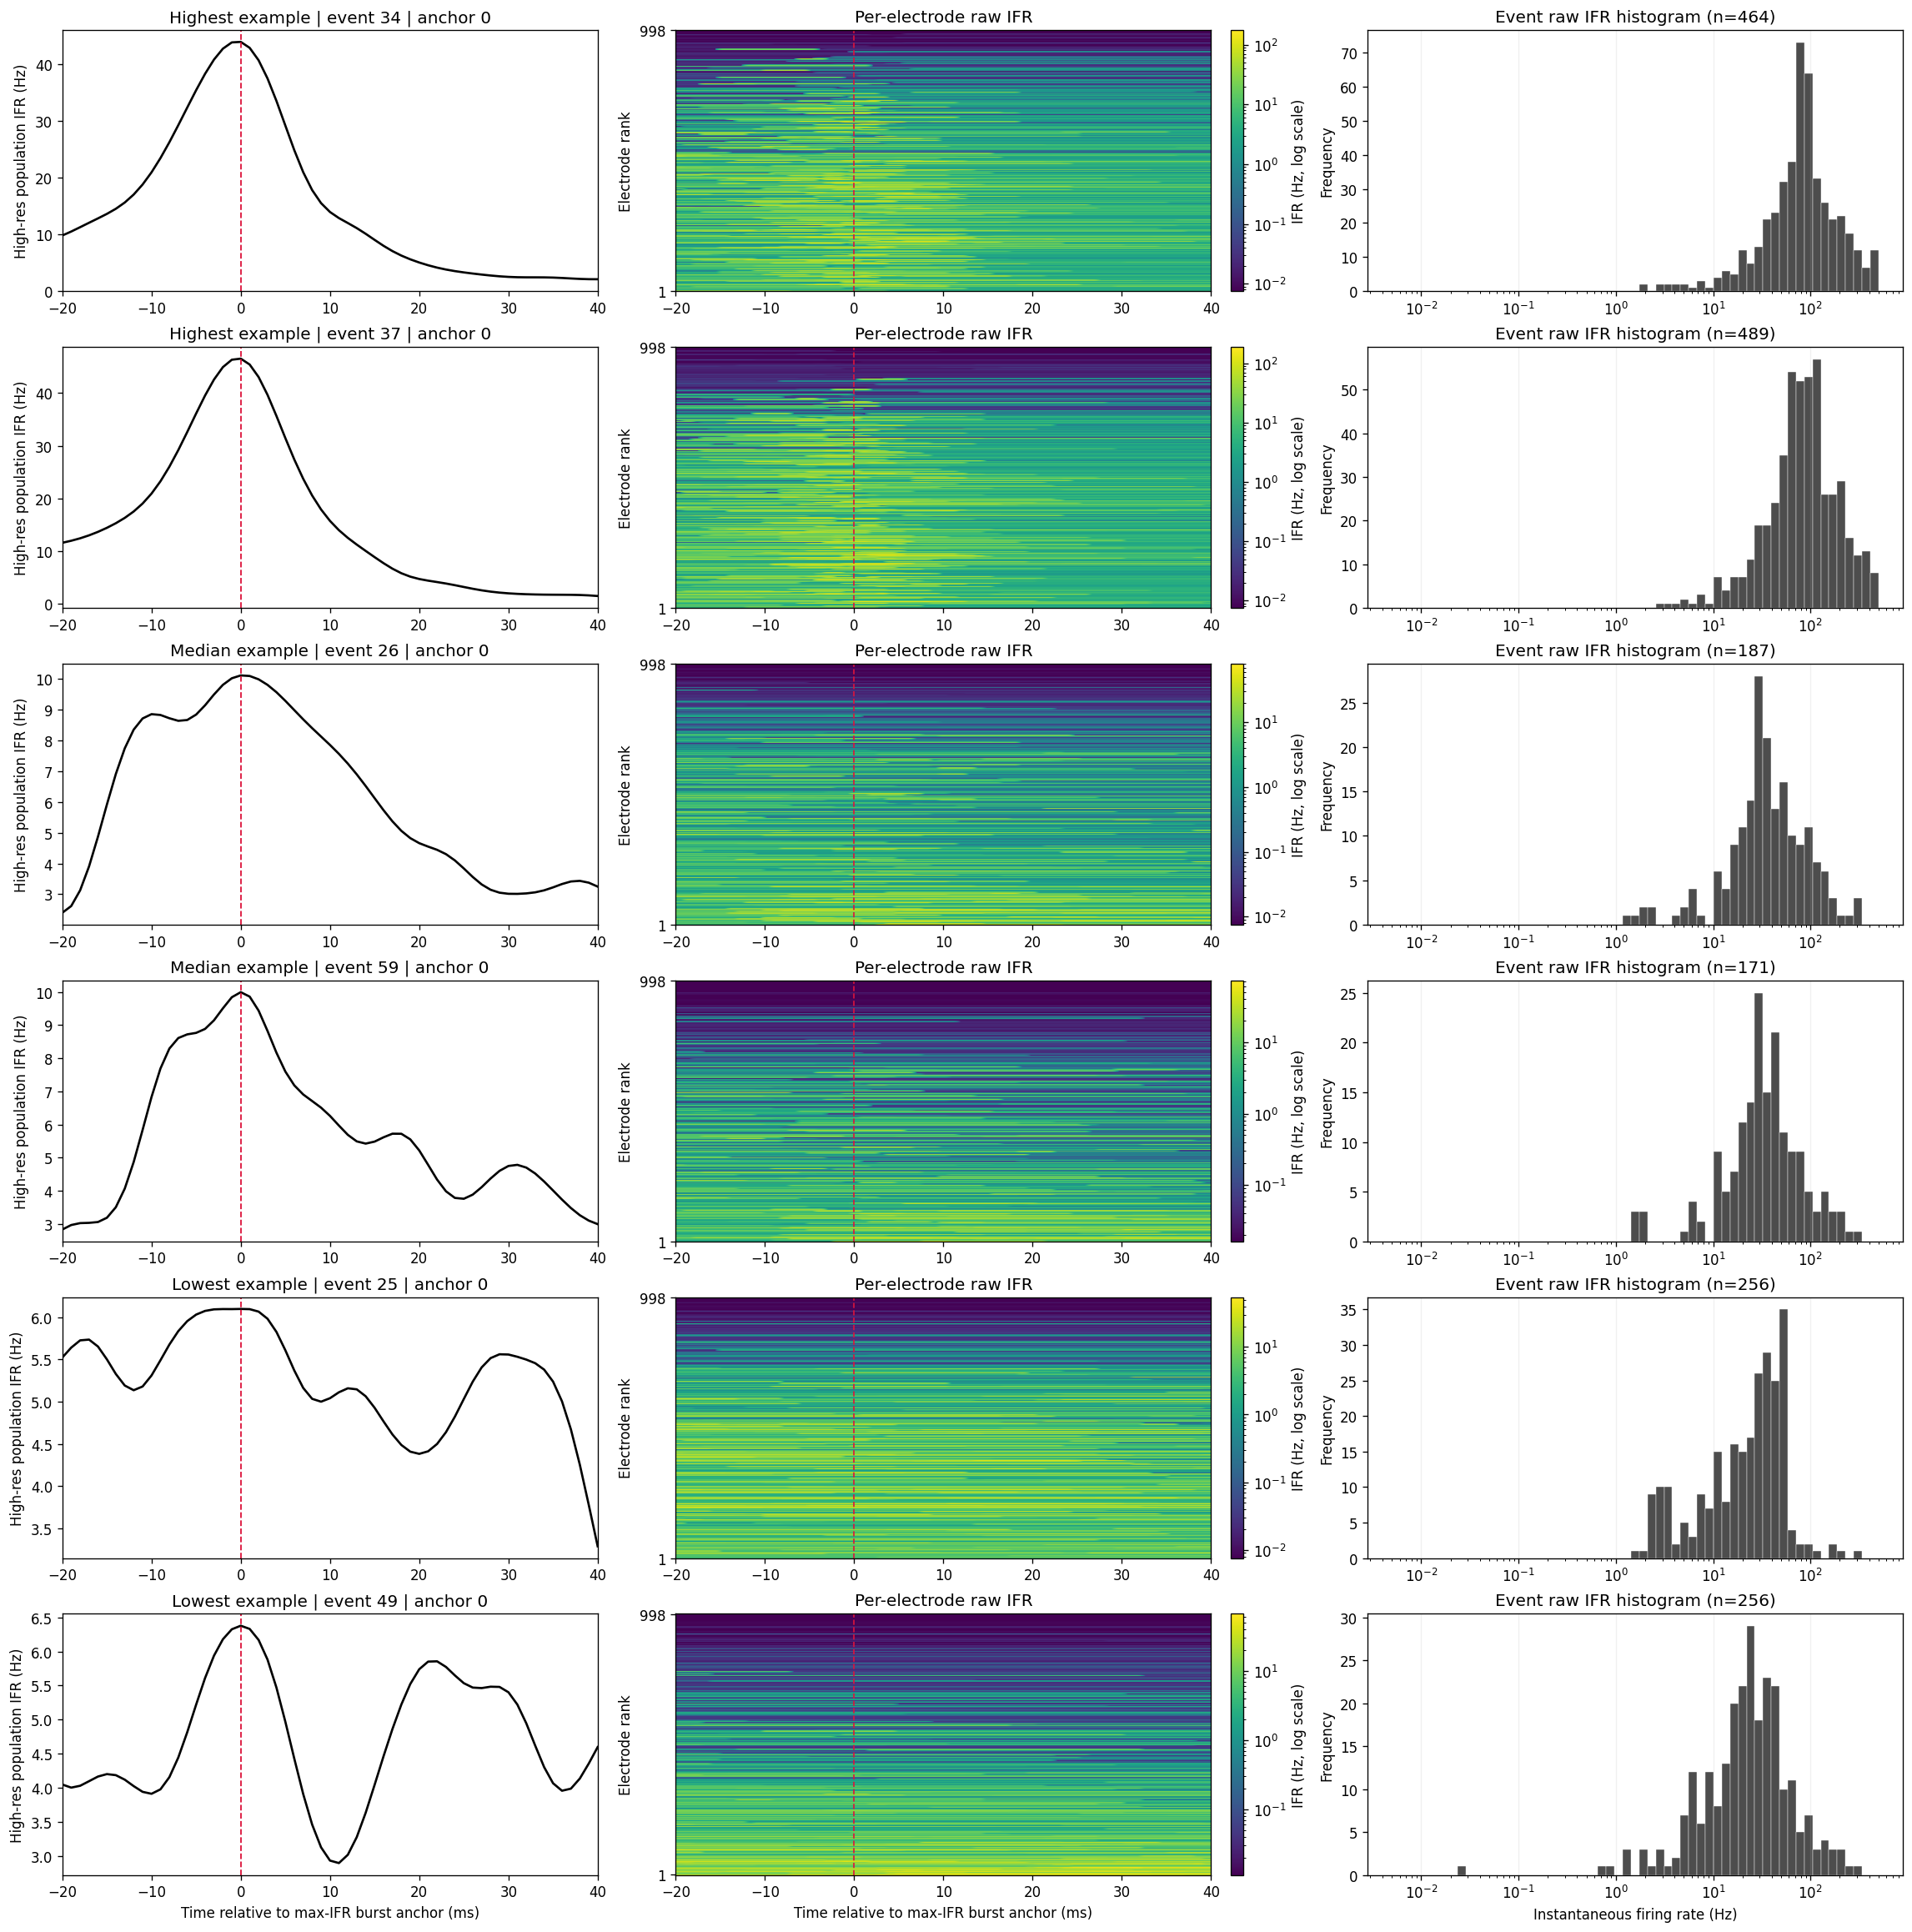

,coarse_event_idx,gamma_peak_rank,anchor_time_s,anchor_height_hz,gamma_anchor_delay_ms,subpeak_count,selection_band
0,34,0,175.790,43.984,48.5,1,highest
1,37,0,194.531,46.497,49.5,1,highest
2,26,0,125.877,10.122,15.5,1,median
3,59,0,281.768,9.991,16.5,1,median
4,25,0,125.799,6.097,27.5,1,lowest
5,49,0,238.468,6.377,6.5,1,lowest


In [50]:
if len(valid_nested_anchors) == 0:
    raise ValueError("No valid burst-peak-centered windows were available for event-level inspection.")

raw_ifr_data, _, _ = calculate_ifr(
    rec.spikes,
    refs,
    rec.start_time,
    rec.end_time,
)

selected_electrodes = np.asarray(refs, dtype=int)
spike_times_all = np.asarray(rec.spikes["time"], dtype=float)
spike_electrodes_all = np.asarray(rec.spikes["electrode"], dtype=int)
time_bin_half_width_s = 0.5 * float(HIGHRES_BIN_MS) / 1000.0
time_edges_highres = np.concatenate(
    ([float(time_centers_highres[0]) - time_bin_half_width_s], time_centers_highres + time_bin_half_width_s)
)

raw_ifr_highres = []
spike_presence_highres = []
event_interval_midpoints = {}
event_interval_ifr = {}
for electrode in selected_electrodes:
    if int(electrode) in raw_ifr_data:
        ifr_times, ifr_values = raw_ifr_data[int(electrode)]
        value_idx = np.searchsorted(ifr_times, time_centers_highres, side="right") - 1
        value_idx = np.clip(value_idx, 0, len(ifr_values) - 1)
        raw_ifr_highres.append(ifr_values[value_idx])
    else:
        raw_ifr_highres.append(np.zeros_like(time_centers_highres, dtype=float))

    electrode_spike_times = np.sort(
        spike_times_all[
            (spike_electrodes_all == int(electrode))
            & (spike_times_all >= rec.start_time)
            & (spike_times_all <= rec.end_time)
        ]
    )
    spike_counts_highres, _ = np.histogram(electrode_spike_times, bins=time_edges_highres)
    spike_presence_highres.append(spike_counts_highres > 0)

    if electrode_spike_times.size < 2:
        event_interval_midpoints[int(electrode)] = np.array([], dtype=float)
        event_interval_ifr[int(electrode)] = np.array([], dtype=float)
    else:
        isi_s = np.diff(electrode_spike_times)
        valid_isi = isi_s > 0
        event_interval_midpoints[int(electrode)] = 0.5 * (
            electrode_spike_times[:-1][valid_isi] + electrode_spike_times[1:][valid_isi]
        )
        event_interval_ifr[int(electrode)] = 1.0 / isi_s[valid_isi]

raw_ifr_highres = np.asarray(raw_ifr_highres, dtype=float)
population_mean_raw_ifr = raw_ifr_highres.mean(axis=0)
population_mean_raw_ifr_smooth = gaussian_filter1d(
    population_mean_raw_ifr,
    sigma=max(1e-6, float(HIGHRES_SMOOTH_SIGMA_MS) / float(HIGHRES_BIN_MS)),
    mode="nearest",
)
spike_presence_highres = np.asarray(spike_presence_highres, dtype=bool)
aligned_spike_tensor = []
for row in valid_nested_anchors.itertuples(index=False):
    anchor_idx = int(np.argmin(np.abs(time_centers_highres - row.anchor_time_s)))
    window_start = anchor_idx - pre_bins
    window_stop = anchor_idx + post_bins + 1
    if window_start < 0 or window_stop > len(time_centers_highres):
        continue
    aligned_spike_tensor.append(spike_presence_highres[:, window_start:window_stop])
aligned_spike_tensor = np.asarray(aligned_spike_tensor, dtype=bool)

all_interval_ifr = raw_ifr_highres[(raw_ifr_highres > 0) & (raw_ifr_highres <= IFR_MAX_HZ)].astype(float)
if all_interval_ifr.size == 0:
    raise ValueError("No positive raw IFR values were found for the selected electrodes.")
global_hist_bins_hz = np.logspace(
    np.log10(max(1e-3, float(all_interval_ifr.min()))),
    np.log10(float(all_interval_ifr.max())),
    60,
)

example_events = select_example_events(valid_nested_anchors, EXAMPLE_GAMMA_EVENT_COUNT)
example_event_count = len(example_events)
if example_event_count == 0:
    raise ValueError("No example events were available for event-level inspection.")

fig, axes = plt.subplots(
    example_event_count,
    3,
    figsize=(19, max(3.2 * example_event_count, 4.0)),
    constrained_layout=True,
    squeeze=False,
)

for row_idx, row in enumerate(example_events.itertuples(index=False)):
    anchor_idx = int(np.argmin(np.abs(time_centers_highres - row.anchor_time_s)))
    window_start = anchor_idx - pre_bins
    window_stop = anchor_idx + post_bins + 1
    if window_start < 0 or window_stop > len(time_centers_highres):
        continue

    electrode_window = raw_ifr_highres[:, window_start:window_stop]
    pop_trace = highres.population_rate_hz[window_start:window_stop]
    absolute_window_start = float(time_centers_highres[window_start])
    absolute_window_stop = float(time_centers_highres[window_stop - 1])
    event_interval_ifr_samples = []
    for electrode in selected_electrodes:
        mids = event_interval_midpoints[int(electrode)]
        vals = event_interval_ifr[int(electrode)]
        in_window = (mids >= absolute_window_start) & (mids <= absolute_window_stop)
        if np.any(in_window):
            event_interval_ifr_samples.append(vals[in_window])
    event_interval_ifr_samples = (
        np.concatenate(event_interval_ifr_samples).astype(float)
        if event_interval_ifr_samples
        else np.array([], dtype=float)
    )

    ax_line = axes[row_idx, 0]
    ax_heat = axes[row_idx, 1]
    ax_hist = axes[row_idx, 2]

    ax_line.plot(relative_time_ms, pop_trace, color="black", lw=1.6)
    ax_line.axvline(0.0, color="crimson", ls="--", lw=1.1)
    ax_line.set_ylabel("High-res population IFR (Hz)")
    ax_line.set_title(
        f"{str(row.selection_band).title()} example | event {int(row.coarse_event_idx)} | anchor {int(row.gamma_peak_rank)}"
    )
    ax_line.set_xlim(float(relative_time_ms[0]), float(relative_time_ms[-1]))

    positive_vals = electrode_window[electrode_window > 0]
    if positive_vals.size == 0:
        heat_vmin = 1e-3
        heat_vmax = 1.0
    else:
        heat_vmin = max(1e-3, float(np.quantile(positive_vals, 0.02)))
        heat_vmax = max(heat_vmin * 10.0, float(np.quantile(positive_vals, 0.995)))
    display_window = np.clip(electrode_window, heat_vmin, heat_vmax)

    im = ax_heat.imshow(
        display_window,
        aspect="auto",
        origin="lower",
        extent=[float(relative_time_ms[0]), float(relative_time_ms[-1]), 0.5, electrode_window.shape[0] + 0.5],
        cmap="viridis",
        norm=LogNorm(vmin=heat_vmin, vmax=heat_vmax),
    )
    ax_heat.axvline(0.0, color="crimson", ls="--", lw=1.0)
    ax_heat.set_title("Per-electrode raw IFR")
    ax_heat.set_ylabel("Electrode rank")
    ax_heat.set_yticks([1, electrode_window.shape[0]])
    ax_heat.set_xlim(float(relative_time_ms[0]), float(relative_time_ms[-1]))

    event_interval_ifr_samples = event_interval_ifr_samples[
        np.isfinite(event_interval_ifr_samples)
        & (event_interval_ifr_samples > 0)
        & (event_interval_ifr_samples <= IFR_MAX_HZ)
    ]
    if event_interval_ifr_samples.size > 0:
        ax_hist.hist(
            event_interval_ifr_samples,
            bins=global_hist_bins_hz,
            color="0.30",
            edgecolor="white",
            linewidth=0.25,
        )
    ax_hist.set_title(f"Event raw IFR histogram (n={int(event_interval_ifr_samples.size)})")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(True, axis="x", alpha=0.18)
    ax_hist.set_xscale("log")

    if row_idx == example_event_count - 1:
        ax_line.set_xlabel("Time relative to max-IFR burst anchor (ms)")
        ax_heat.set_xlabel("Time relative to max-IFR burst anchor (ms)")
        ax_hist.set_xlabel("Instantaneous firing rate (Hz)")

    cbar = fig.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.02)
    cbar.set_label("IFR (Hz, log scale)")
    cbar.locator = LogLocator(base=10)
    cbar.formatter = LogFormatterMathtext(base=10)
    cbar.update_ticks()

save_inline_plot(fig, "example_event_raw_ifr_inspection")

example_events[[
    "coarse_event_idx",
    "gamma_peak_rank",
    "anchor_time_s",
    "anchor_height_hz",
    "gamma_anchor_delay_ms",
    "subpeak_count",
    "selection_band",
]].round(3)


## Next Step

The notebook now uses nested anchoring, ranks electrodes by peak-window IFR, shows an x-ordered propagation view, and renders a coarse hex-binned burst-peak-centered GIF. The next useful refinement is to compare this average-array GIF against event-specific GIFs from only the strongest bursts, so that propagation structure is not averaged away.
